In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
import torch
import torch.nn as nn
import h5py
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm


warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['figure.dpi'] = 200 # plots quality


path='/content/drive/Shareddrives/XAI Project Shared Drive'

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
X = np.load(f'{path}/X_100hz.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')
df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

print(f"Signal Data Shape [Samples, Time, Leads]: {X.shape}")
print(f"Metadata Shape: {df_ptbxl.shape}")


Signal Data Shape [Samples, Time, Leads]: (21799, 1000, 12)
Metadata Shape: (21799, 27)


In [3]:
print(len(df_ptbxl['patient_id'].unique()), "patients")

18869 patients


In [20]:
agg_df = pd.read_csv(f'{path}/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dict):
    tmp = []
    for key in y_dict.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

df_ptbxl['diagnostic_superclass'] = df_ptbxl.scp_codes.apply(aggregate_diagnostic)


superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for sc in superclasses:
    df_ptbxl[sc] = df_ptbxl['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)

print("\nSample of Superclass Targets:")
display(df_ptbxl[['diagnostic_superclass'] + superclasses].head())


Sample of Superclass Targets:


,diagnostic_superclass,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,
1,[NORM],1,0,0,0,0
2,[NORM],1,0,0,0,0
3,[NORM],1,0,0,0,0
4,[NORM],1,0,0,0,0
5,[NORM],1,0,0,0,0


## Model 3: ACO-FCN (Radwan)

In [4]:
import os
import numpy as np
import pywt
from scipy.signal import hilbert
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, multilabel_confusion_matrix, roc_curve
from sklearn.metrics import f1_score
import torch
import torch.optim as optim
import torch.nn.functional as F
from tqdm.auto import tqdm
import time

### Pipelines & Models implementations

#### Preprocessing

In [5]:
class ECGPreprocessor:
    """
    Applies Multi-Resolution Wavelet (MRW) Denoising and Z-score normalization.
    """
    def __init__(self, wavelet='db4', mrw_level=4):
        self.wavelet = wavelet
        self.mrw_level = mrw_level

    def filter_nans(self, X, Y):

        valid_indices = ~np.isnan(X).any(axis=(1, 2))
        return X[valid_indices], Y[valid_indices]

    def _denoise_and_normalize(self, signal):
        coeffs = pywt.wavedec(signal, self.wavelet, level=self.mrw_level)

        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        uthresh = sigma * np.sqrt(2 * np.log(len(signal)))

        denoised_coeffs = [np.zeros_like(coeffs[0])] + [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:]]
        denoised_signal = pywt.waverec(denoised_coeffs, self.wavelet)[:len(signal)]

        mean_val = np.mean(denoised_signal)
        std_val = np.std(denoised_signal)
        normalized_signal = (denoised_signal - mean_val) / (std_val + 1e-8)

        return normalized_signal

    def transform(self, X_raw):
        print("Starting Preprocessing...")
        X_clean = np.zeros_like(X_raw, dtype=np.float32)
        num_samples, _, num_leads = X_raw.shape

        for i in tqdm(range(num_samples)):
            for lead in range(num_leads):
                X_clean[i, :, lead] = self._denoise_and_normalize(X_raw[i, :, lead])

            if (i + 1) % 1000 == 0:
                print(f"Preprocessed {i + 1} / {num_samples} samples.")

        return X_clean

#### Feature Extractor

In [6]:
class ECGFeatureExtractor:
    """
    Applies Stationary Wavelet Transform (SWT) and Hilbert Transform (HT)
    to extract statistical features from instantaneous amplitude and frequency.
    """
    def __init__(self, wavelet='db4', swt_level=3, fs=100):
        self.wavelet = wavelet
        self.swt_level = swt_level
        self.fs = fs
        self.features_per_lead = swt_level * 2 * 4

    def _extract_lead_features(self, signal):
        pad_len = int(np.ceil(len(signal) / (2**self.swt_level)) * (2**self.swt_level))
        padded_signal = np.pad(signal, (0, pad_len - len(signal)), 'constant')

        coeffs = pywt.swt(padded_signal, self.wavelet, level=self.swt_level)
        features = []

        for cA, cD in coeffs:
            analytic_signal = hilbert(cD)

            inst_amplitude = np.abs(analytic_signal)
            inst_phase = np.unwrap(np.angle(analytic_signal))

            inst_frequency = (np.diff(inst_phase) / (2.0 * np.pi)) * self.fs
            inst_frequency = np.append(inst_frequency, inst_frequency[-1])

            for metric in [inst_amplitude, inst_frequency]:
                features.extend([
                    np.mean(metric),
                    np.std(metric),
                    skew(metric),
                    kurtosis(metric)
                ])

        features = np.nan_to_num(features, nan=0.0)
        return features

    def transform(self, X_clean):
        print("Starting Feature Extraction...")
        num_samples, _, num_leads = X_clean.shape
        total_features = num_leads * self.features_per_lead

        X_features = np.zeros((num_samples, total_features), dtype=np.float32)

        for i in tqdm(range(num_samples)):
            sample_features = []
            for lead in range(num_leads):
                lead_features = self._extract_lead_features(X_clean[i, :, lead])
                sample_features.extend(lead_features)

            X_features[i, :] = sample_features

            if (i + 1) % 1000 == 0:
                print(f"Extracted features for {i + 1} / {num_samples} samples.")

        return X_features

### Dataset

In [7]:
class ECGFeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

#### Loss Function

In [8]:
class MultiLabelFocalLoss(nn.Module):
    """
    Advanced Focal Loss tailored for Multi-Label Imbalanced Medical Data.
    Down-weights easy examples and focuses on hard-to-classify signals.
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(MultiLabelFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)

        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return torch.mean(focal_loss)
        return focal_loss

#### FCN Archticure

In [9]:
class FCN(nn.Module):
    def __init__(self, input_features, num_classes=5, num_filters=16, kernel_size=3, dense_units=64, dropout_rate=0.6):
        super(FCN, self).__init__()

        self.conv_blocks = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size, padding='same'),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=num_filters, out_channels=num_filters*2, kernel_size=kernel_size, padding='same'),
            nn.BatchNorm1d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        dummy_input = torch.zeros(1, 1, input_features)
        dummy_output = self.conv_blocks(dummy_input)
        self.flattened_size = dummy_output.view(1, -1).size(1)


        self.dense_blocks = nn.Sequential(
            nn.Linear(self.flattened_size, dense_units),
            nn.BatchNorm1d(dense_units),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),

            nn.Linear(dense_units, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        x = self.dense_blocks(x)
        return x

#### Ant Colony Optimization

In [10]:
class ACO_Optimizer:
    def __init__(self, search_space, num_ants=5, num_iterations=10, evaporation_rate=0.2, proxy_epochs=5, device='cuda'):
        """
        Ant Colony Optimization for CNN Hyperparameters.

        search_space: dict of hyperparameter lists (e.g., {'lr': [0.001, 0.01], 'dropout': [0.4, 0.6]})
        num_ants: How many parameter combinations to test per generation.
        num_iterations: How many generations the colony will run.
        evaporation_rate: How fast old pheromones disappear (0.0 to 1.0).
        proxy_epochs: How many epochs to train each ant (keep low to save time, e.g., 5).
        """
        self.search_space = search_space
        self.num_ants = num_ants
        self.num_iterations = num_iterations
        self.evaporation_rate = evaporation_rate
        self.proxy_epochs = proxy_epochs
        self.device = device

        self.pheromones = {
            param: np.ones(len(values)) for param, values in search_space.items()
        }

        self.best_overall_hparams = None
        self.best_overall_score = 0.0

    def _construct_solution(self):
        """An ant walks the paths and selects one value per hyperparameter based on pheromones."""
        solution = {}
        solution_indices = {}

        for param, values in self.search_space.items():
            phero_levels = self.pheromones[param]
            probabilities = phero_levels / phero_levels.sum()

            chosen_idx = np.random.choice(len(values), p=probabilities)
            solution[param] = values[chosen_idx]
            solution_indices[param] = chosen_idx

        return solution, solution_indices

    def _evaluate_solution(self, hparams, input_features, train_loader, val_loader):
        """Builds the FCN, trains it for `proxy_epochs`, and returns the Validation F1-Score."""
        # model
        model = FCN(
            input_features=input_features,
            num_filters=hparams['num_filters'],
            kernel_size=hparams['kernel_size'],
            dense_units=hparams['dense_units'],
            dropout_rate=hparams['dropout_rate']
        ).to(self.device)

        # loss
        criterion = MultiLabelFocalLoss(alpha=0.25, gamma=2.0).to(self.device)
        optimizer = optim.Adam(model.parameters(), lr=hparams['lr'], weight_decay=1e-4)

        # proxy evaluation
        for epoch in range(self.proxy_epochs):
            model.train()
            for features, labels in train_loader:
                features, labels = features.to(self.device), labels.float().to(self.device)
                optimizer.zero_grad()
                outputs = model(features)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # validation
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(self.device), labels.float().to(self.device)
                probs = torch.sigmoid(model(features))
                preds = (probs > 0.5).int()

                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        score = f1_score(val_targets, val_preds, average='micro', zero_division=0) # ant score
        return score

    def optimize(self, input_features, train_loader, val_loader):
        print(f"--- Starting Ant Colony Optimization ---")
        print(f"Search Space: {self.search_space.keys()}")

        for iteration in range(self.num_iterations):
            print(f"\nGeneration {iteration + 1}/{self.num_iterations}")

            ant_solutions = []
            ant_indices = []
            ant_scores = []

            # send ants
            for ant in tqdm(range(self.num_ants)):
                hparams, indices = self._construct_solution()
                print(f"  Ant {ant+1} testing: {hparams}")

                score = self._evaluate_solution(hparams, input_features, train_loader, val_loader)
                print(f"  Ant {ant+1} Score (Val F1): {score:.4f}")

                ant_solutions.append(hparams)
                ant_indices.append(indices)
                ant_scores.append(score)

                # track the global best
                if score > self.best_overall_score:
                    self.best_overall_score = score
                    self.best_overall_hparams = hparams
                    print(f"  *** NEW GLOBAL BEST! ***")

            # evaporate Pheromones (Old paths fade away)
            for param in self.pheromones:
                self.pheromones[param] *= (1.0 - self.evaporation_rate)

            # Step 3: Deposit New Pheromones (Reward the best paths from this generation)
            # We scale the reward by the score so better ants leave more pheromones
            for ant_idx in tqdm(range(self.num_ants)):
                score = ant_scores[ant_idx]
                indices = ant_indices[ant_idx]

                # only reward ants that learned something to avoid dropping pheromones on zero-score models
                if score > 0.01:
                    for param, val_idx in indices.items():
                        self.pheromones[param][val_idx] += score

        print("\n=========================================")
        print("ACO Complete! Optimal Hyperparameters Found:")
        print(self.best_overall_hparams)
        print(f"Estimated Proxy F1-Score: {self.best_overall_score:.4f}")
        print("=========================================")

        return self.best_overall_hparams

### Preprocessing

In [11]:
preprocessor = ECGPreprocessor(wavelet='db4')
X_cleaned = preprocessor.transform(X)

Starting Preprocessing...


  0%|          | 0/21799 [00:00<?, ?it/s]

Preprocessed 1000 / 21799 samples.
Preprocessed 2000 / 21799 samples.
Preprocessed 3000 / 21799 samples.
Preprocessed 4000 / 21799 samples.
Preprocessed 5000 / 21799 samples.
Preprocessed 6000 / 21799 samples.
Preprocessed 7000 / 21799 samples.
Preprocessed 8000 / 21799 samples.
Preprocessed 9000 / 21799 samples.
Preprocessed 10000 / 21799 samples.
Preprocessed 11000 / 21799 samples.
Preprocessed 12000 / 21799 samples.
Preprocessed 13000 / 21799 samples.
Preprocessed 14000 / 21799 samples.
Preprocessed 15000 / 21799 samples.
Preprocessed 16000 / 21799 samples.
Preprocessed 17000 / 21799 samples.
Preprocessed 18000 / 21799 samples.
Preprocessed 19000 / 21799 samples.
Preprocessed 20000 / 21799 samples.
Preprocessed 21000 / 21799 samples.


In [12]:
def visualize_your_preprocessing(raw_signal, fs=100, wavelet='db4', level=4):
    time_axis = np.arange(len(raw_signal)) / fs

    # 1. Replicate your Denoising Step
    coeffs = pywt.wavedec(raw_signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(raw_signal)))

    denoised_coeffs = [np.zeros_like(coeffs[0])] + [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:]]
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)[:len(raw_signal)]

    # 2. Replicate your Normalization Step
    mean_val = np.mean(denoised_signal)
    std_val = np.std(denoised_signal)
    normalized_signal = (denoised_signal - mean_val) / (std_val + 1e-8)

    # ==========================================
    # PLOTTING THE 3-PANEL FIGURE
    # ==========================================
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle("Signal Preprocessing (MRW Denoising & Z-Score)", fontsize=16, fontweight='bold')

    # PANEL 1: The Raw, Noisy Signal
    axes[0].plot(time_axis, raw_signal, color='gray', linewidth=1.5)
    axes[0].set_title("1. Raw ECG Signal", fontsize=12, loc='left')
    axes[0].set_ylabel("Raw mV")
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # PANEL 2: The MRW Overlay
    axes[1].plot(time_axis, raw_signal, color='gray', alpha=0.4, label='Raw Signal')
    axes[1].plot(time_axis, denoised_signal, color='#1f77b4', linewidth=2, label='MRW Denoised')
    axes[1].set_title(f"2. MRW Denoising Applied ({wavelet} Level {level})", fontsize=12, loc='left')
    axes[1].set_ylabel("Cleaned mV")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # PANEL 3: Z-Score Normalization
    axes[2].plot(time_axis, normalized_signal, color='#d62728', linewidth=1.5)
    axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
    axes[2].set_title("3. Z-Score Normalization (Standardized scale for Neural Network)", fontsize=12, loc='left')
    axes[2].set_ylabel("Standard Deviations (Z)")
    axes[2].set_xlabel("Time (Seconds)", fontsize=12)
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

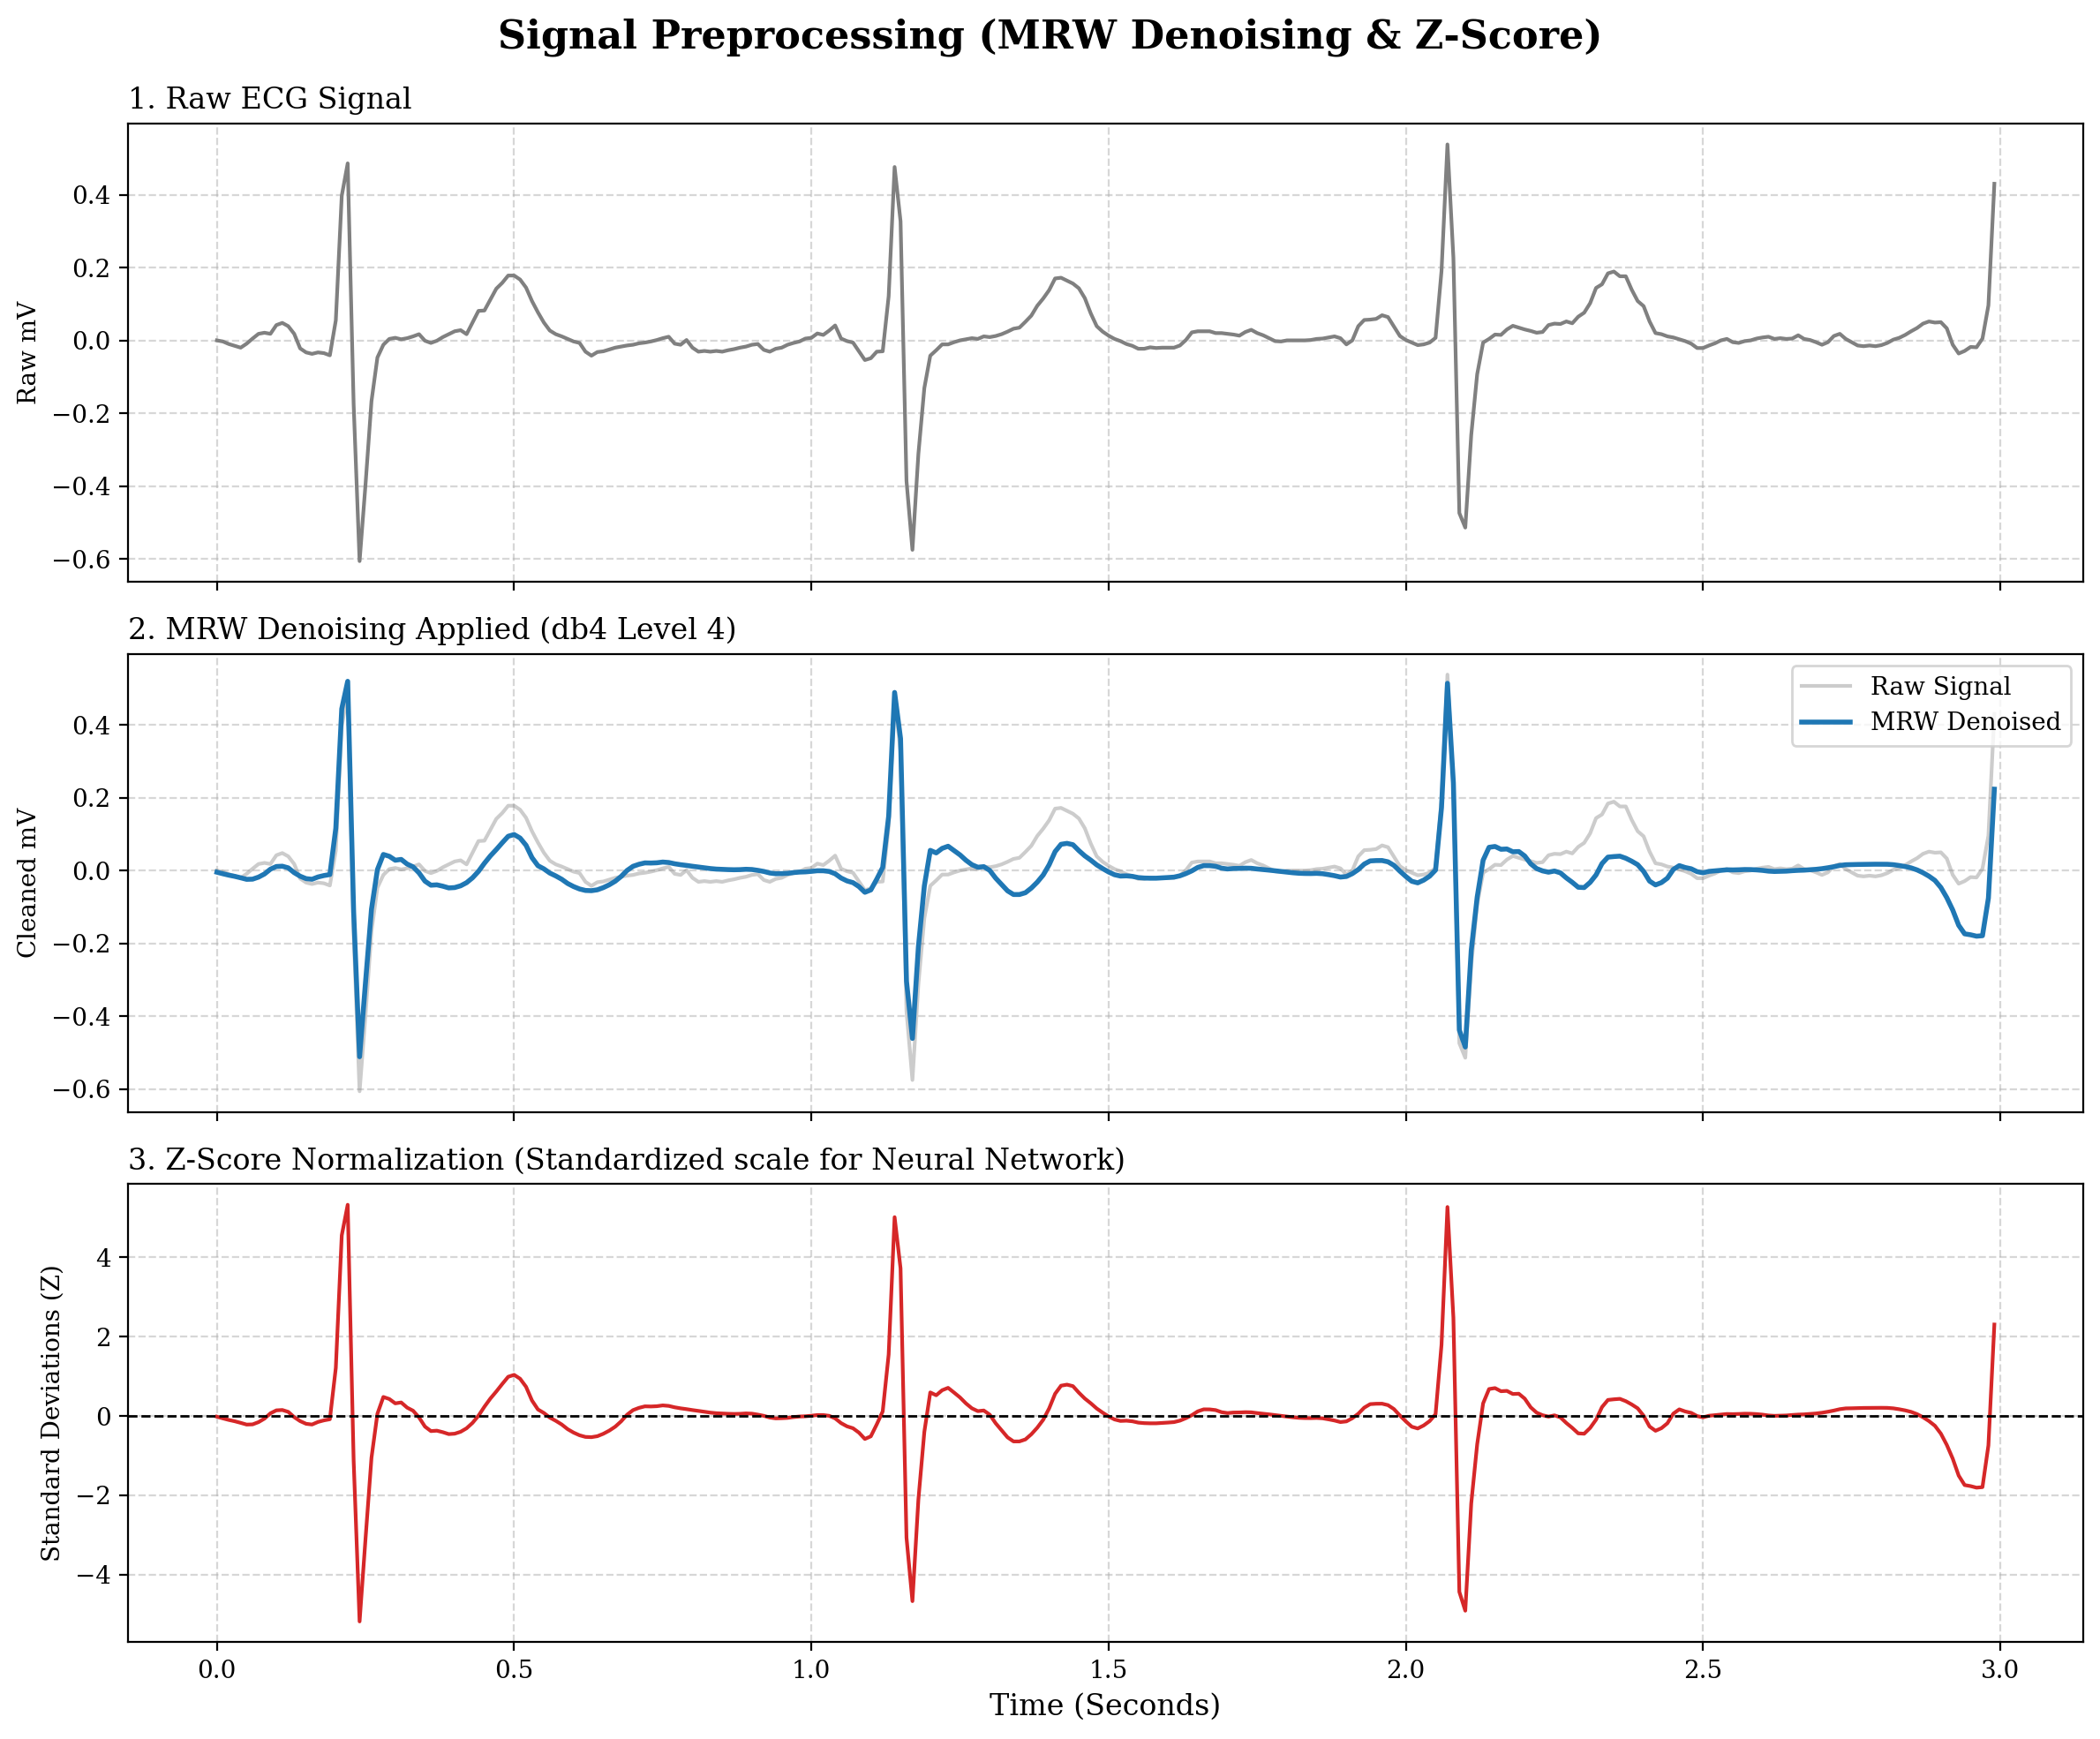

In [13]:
PATIENT_IDX = 0
LEAD_IDX = 8
time_window = 300

sample_raw_wave = X[PATIENT_IDX, :time_window, LEAD_IDX]

visualize_your_preprocessing(sample_raw_wave, fs=100, wavelet='db4', level=4)

### Feature Extraction

In [ ]:
feature_extractor = ECGFeatureExtractor(wavelet='db4', swt_level=3, fs=100)
X_processed = feature_extractor.transform(X_cleaned)

Starting Feature Extraction...


  0%|          | 0/21799 [00:00<?, ?it/s]

Extracted features for 1000 / 21799 samples.
Extracted features for 2000 / 21799 samples.


In [14]:
# saved preprocessed data from previous sessions because feature extraction take about one hour :)

data = np.load(path + '/ACOFCN_complete_data.npz')
X_processed= data['X_processed']

In [15]:
def visualize_feature_extraction(signal, fs=100, wavelet='db4', swt_level=3, plot_level=2):
    """
    Generates a publication-ready visualization of the SWT and Hilbert Transform step.

    signal: A 1D numpy array representing a single cleaned ECG lead
    plot_level: Which SWT level to visualize (Level 2 is usually great for QRS complexes)
    """
    pad_len = int(np.ceil(len(signal) / (2**swt_level)) * (2**swt_level))
    padded_signal = np.pad(signal, (0, pad_len - len(signal)), 'constant')

    time_axis = np.arange(len(padded_signal)) / fs

    coeffs = pywt.swt(padded_signal, wavelet, level=swt_level)

    target_idx = swt_level - plot_level
    cA, cD = coeffs[target_idx]

    analytic_signal = hilbert(cD)
    inst_amplitude = np.abs(analytic_signal)
    inst_phase = np.unwrap(np.angle(analytic_signal))

    inst_frequency = (np.diff(inst_phase) / (2.0 * np.pi)) * fs
    inst_frequency = np.append(inst_frequency, inst_frequency[-1])

    # ==========================================
    # PLOTTING THE 4-PANEL FIGURE
    # ==========================================
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Feature Extraction (SWT Level {plot_level} & Hilbert Transform)", fontsize=16, fontweight='bold')

    # PANEL 1: original clean signal
    axes[0].plot(time_axis, padded_signal, color='#1f77b4', linewidth=2)
    axes[0].set_title("1. Cleaned ECG Input Signal", fontsize=12, loc='left')
    axes[0].set_ylabel("Amplitude (Z)")
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # PANEL 2: SWT detail coefficient
    axes[1].plot(time_axis, cD, color='#2ca02c', linewidth=1.5)
    axes[1].set_title(f"2. SWT Detail Coefficient (Isolating specific frequency bands)", fontsize=12, loc='left')
    axes[1].set_ylabel("Coefficient")
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # PANEL 3: instantaneous amplitude (Overlay)
    axes[2].plot(time_axis, cD, color='gray', alpha=0.5, label='SWT Coefficient', linestyle='--')
    axes[2].plot(time_axis, inst_amplitude, color='#d62728', linewidth=2.5, label='Instantaneous Amplitude (Envelope)')
    axes[2].set_title("3. Hilbert Transform: Instantaneous Amplitude", fontsize=12, loc='left')
    axes[2].set_ylabel("Energy")
    axes[2].legend(loc="upper right")
    axes[2].grid(True, linestyle='--', alpha=0.6)

    # PANEL 4: instantaneous frequency
    axes[3].plot(time_axis, inst_frequency, color='#9467bd', linewidth=1.5)
    axes[3].set_title("4. Hilbert Transform: Instantaneous Frequency", fontsize=12, loc='left')
    axes[3].set_ylabel("Frequency (Hz)")
    axes[3].set_xlabel("Time (Seconds)", fontsize=12)
    axes[3].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

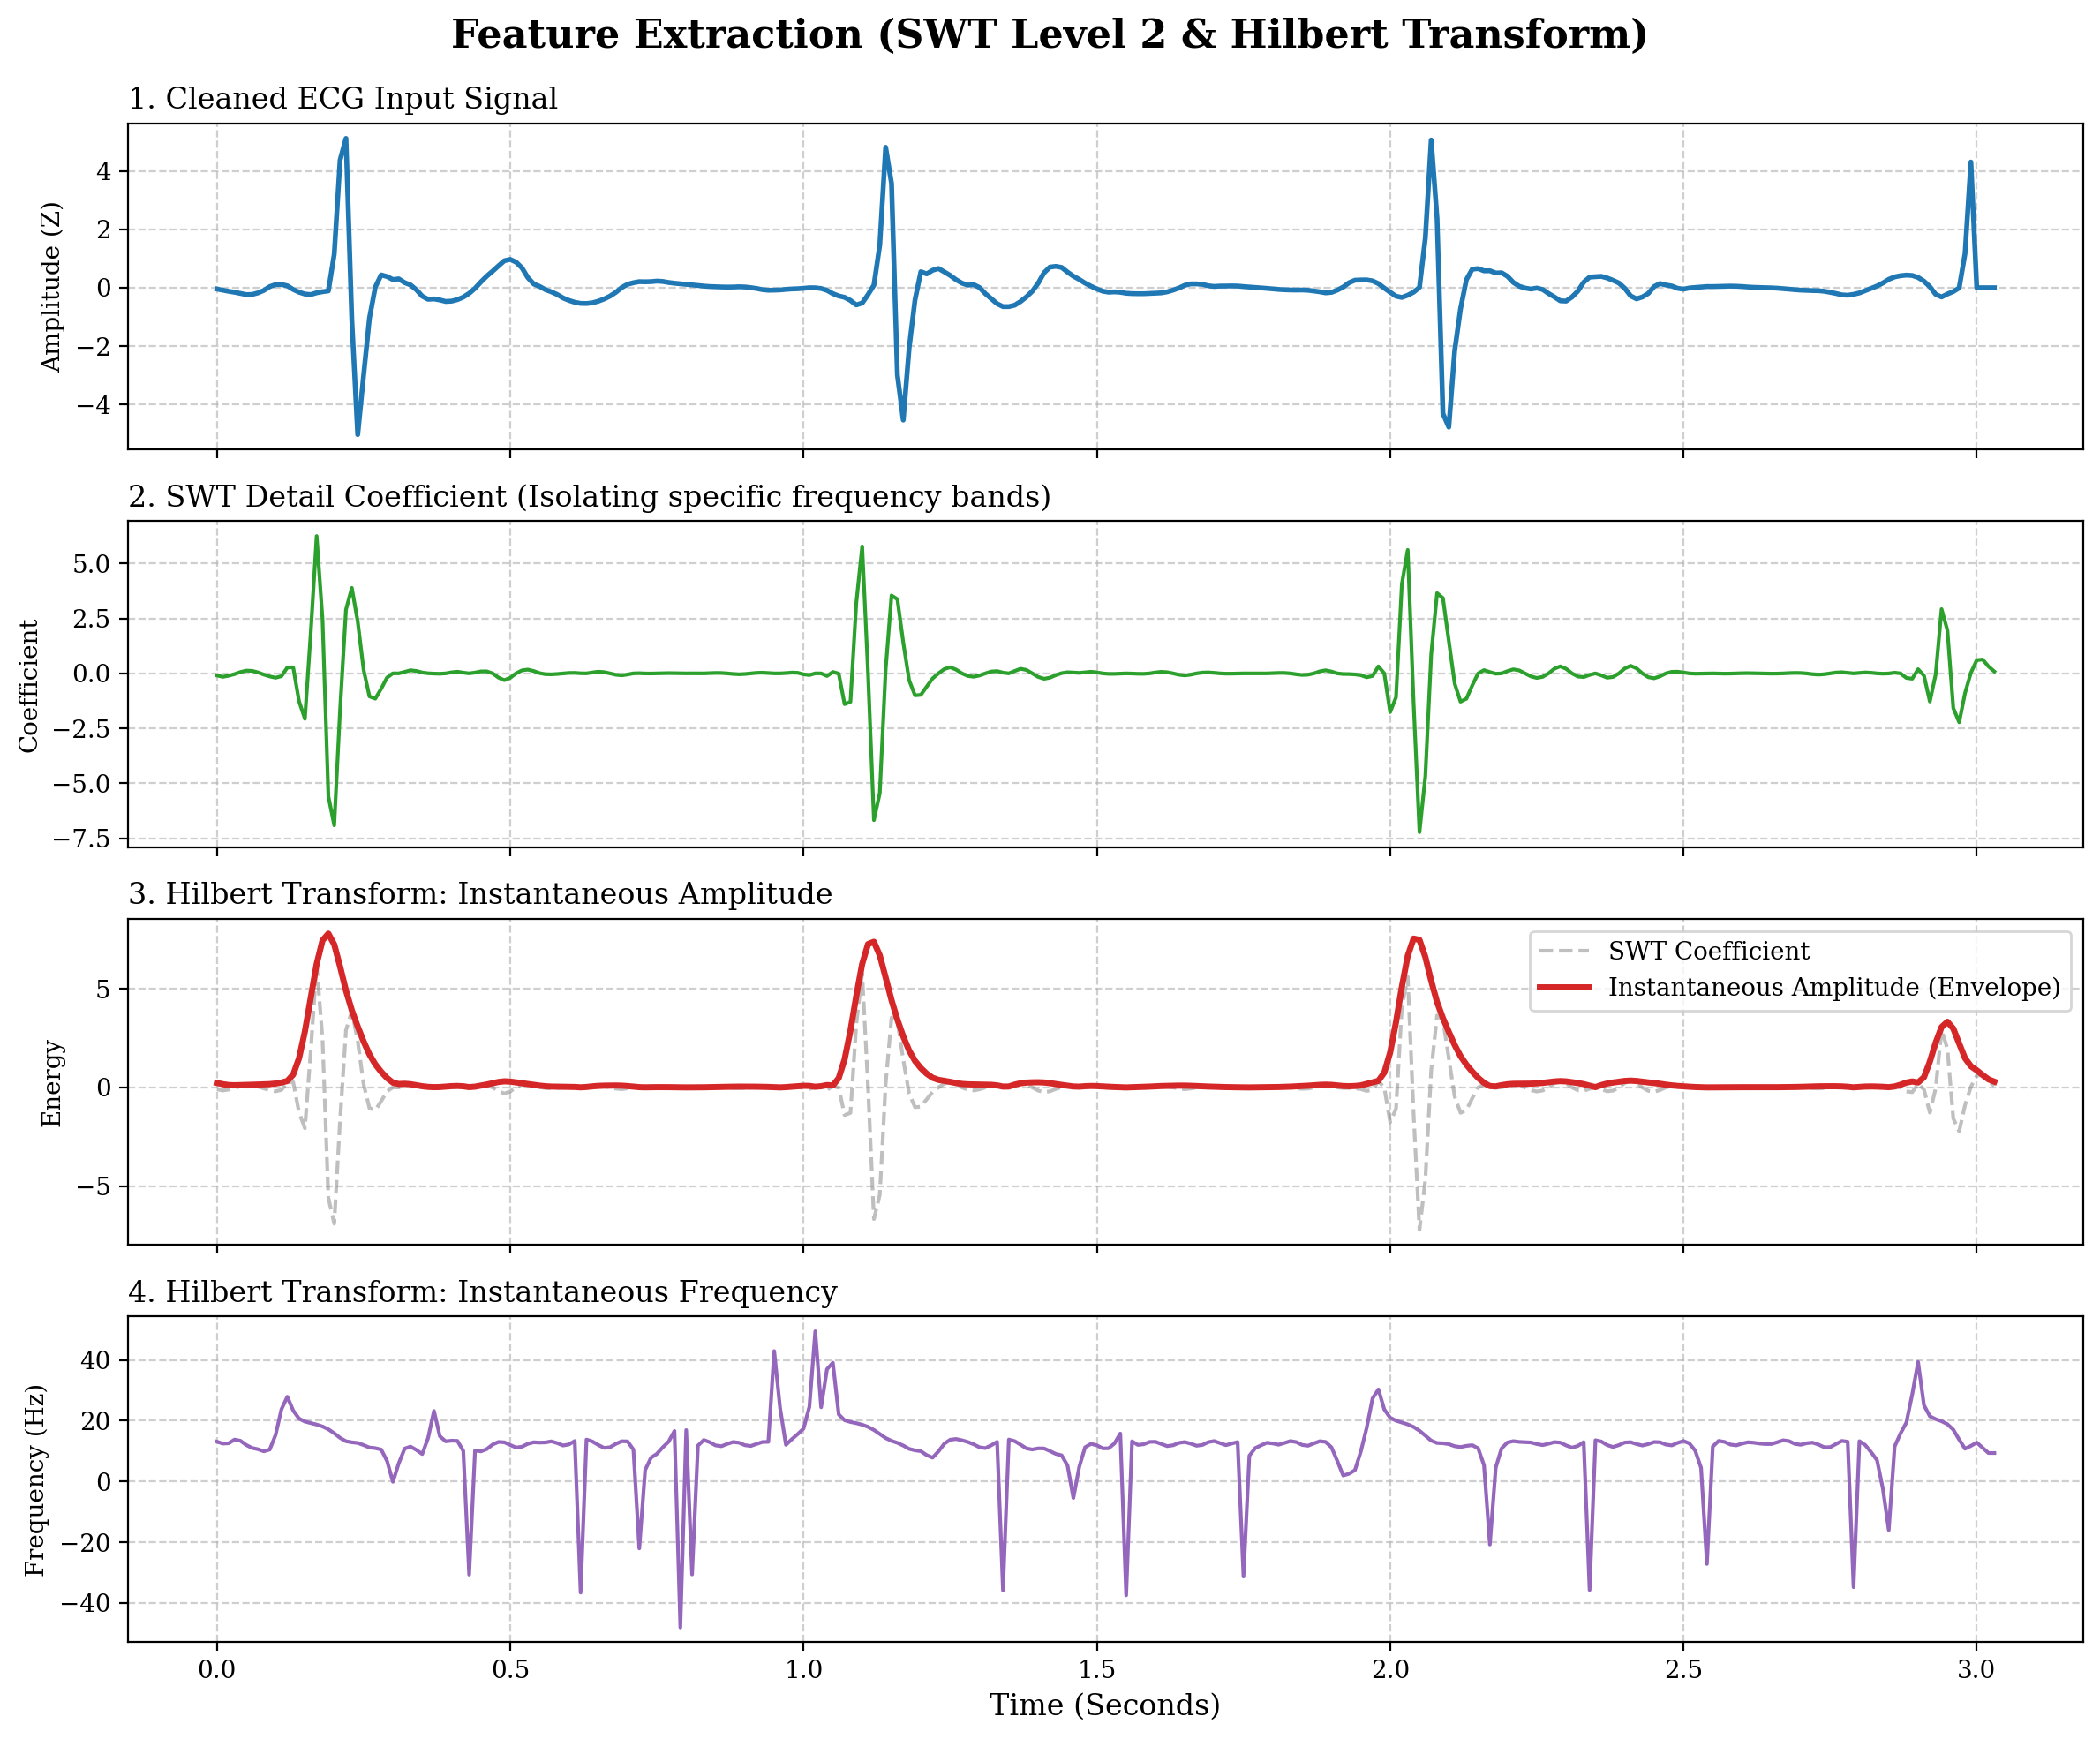

In [16]:
PATIENT_IDX = 0
LEAD_IDX = 8
time_window = 300

sample_clean_wave = X_cleaned[PATIENT_IDX, :time_window, LEAD_IDX]

visualize_feature_extraction(sample_clean_wave, fs=100, wavelet='db4', swt_level=3, plot_level=2)

### Split the data

In [18]:
superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

In [21]:
Y= df_ptbxl[superclasses].values

X_train, X_temp, Y_train, Y_temp = train_test_split(X_processed, Y, test_size=0.20, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42)

batch_size = 64
train_dataset = ECGFeatureDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = ECGFeatureDataset(X_val, Y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = ECGFeatureDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [22]:
print(f"Final Feature Matrix Shape: {X_processed.shape}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Final Feature Matrix Shape: (21799, 288)
Train batches: 273 | Val batches: 35 | Test batches: 35


### Hyperparamter Search (ACO)

In [ ]:
search_space = {
    'num_filters': [8, 16, 32, 64],
    'kernel_size': [3, 5, 7],
    'dense_units': [32, 64, 128],
    'dropout_rate': [0.4, 0.5, 0.6, 0.7],
    'lr': [1e-4, 5e-4, 1e-3, 5e-3]
}

input_feature_size = X_train.shape[1]

aco = ACO_Optimizer(
    search_space=search_space,
    num_ants=5,
    num_iterations=10,
    evaporation_rate=0.2,
    proxy_epochs=5,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

best_hparams = aco.optimize(
    input_features=input_feature_size,
    train_loader=train_loader,
    val_loader=val_loader
)

print("best params:", best_hparams)

--- Starting Ant Colony Optimization ---
Search Space: dict_keys(['num_filters', 'kernel_size', 'dense_units', 'dropout_rate', 'lr'])

Generation 1/10


  0%|          | 0/5 [00:00<?, ?it/s]

  Ant 1 testing: {'num_filters': 64, 'kernel_size': 7, 'dense_units': 64, 'dropout_rate': 0.4, 'lr': 0.0001}
  Ant 1 Score (Val F1): 0.5308
  *** NEW GLOBAL BEST! ***
  Ant 2 testing: {'num_filters': 8, 'kernel_size': 7, 'dense_units': 64, 'dropout_rate': 0.6, 'lr': 0.0005}
  Ant 2 Score (Val F1): 0.4299
  Ant 3 testing: {'num_filters': 16, 'kernel_size': 3, 'dense_units': 32, 'dropout_rate': 0.7, 'lr': 0.001}
  Ant 3 Score (Val F1): 0.3410
  Ant 4 testing: {'num_filters': 8, 'kernel_size': 3, 'dense_units': 64, 'dropout_rate': 0.5, 'lr': 0.0005}
  Ant 4 Score (Val F1): 0.5235
  Ant 5 testing: {'num_filters': 32, 'kernel_size': 7, 'dense_units': 64, 'dropout_rate': 0.7, 'lr': 0.005}
  Ant 5 Score (Val F1): 0.4750


  0%|          | 0/5 [00:00<?, ?it/s]


Generation 2/10


...


Generation 10/10


  0%|          | 0/5 [00:00<?, ?it/s]

  Ant 1 testing: {'num_filters': 16, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.6, 'lr': 0.0005}
  Ant 1 Score (Val F1): 0.5120
  Ant 2 testing: {'num_filters': 8, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.6, 'lr': 0.0001}
  Ant 2 Score (Val F1): 0.4576
  Ant 3 testing: {'num_filters': 8, 'kernel_size': 7, 'dense_units': 32, 'dropout_rate': 0.6, 'lr': 0.0001}
  Ant 3 Score (Val F1): 0.4017
  Ant 4 testing: {'num_filters': 16, 'kernel_size': 7, 'dense_units': 64, 'dropout_rate': 0.6, 'lr': 0.0001}
  Ant 4 Score (Val F1): 0.4518
  Ant 5 testing: {'num_filters': 16, 'kernel_size': 3, 'dense_units': 64, 'dropout_rate': 0.4, 'lr': 0.0001}
  Ant 5 Score (Val F1): 0.4955


  0%|          | 0/5 [00:00<?, ?it/s]


ACO Complete! Optimal Hyperparameters Found:
{'num_filters': 8, 'kernel_size': 3, 'dense_units': 64, 'dropout_rate': 0.4, 'lr': 0.0005}
Estimated Proxy F1-Score: 0.5551
best params: {'num_filters': 8, 'kernel_size': 3, 'dense_units': 64, 'dropout_rate': 0.4, 'lr': 0.0005}


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_feature_size = X_train.shape[1]

final_model = FCN(
    input_features=input_feature_size,
    num_filters=best_hparams['num_filters'],
    kernel_size=best_hparams['kernel_size'],
    dense_units=best_hparams['dense_units'],
    dropout_rate=best_hparams['dropout_rate'],
).to(device)

criterion = MultiLabelFocalLoss(alpha=0.25, gamma=2.0)

optimizer = optim.Adam(final_model.parameters(), lr=best_hparams['lr'], weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=4, factor=0.5)

### Training

In [ ]:
num_epochs = 50
best_val_loss = float('inf')
patience = 8
patience_counter = 0
best_model_path = 'best_shrink_fcn.pth'

history_train_loss = []
history_val_loss = []
best_epoch = 0

print(f"\nStarting Training on {device}...")

for epoch in range(num_epochs):
    start_time = time.time()
    final_model.train()
    running_train_loss = 0.0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.float().to(device)
        optimizer.zero_grad()
        outputs = final_model(features)

        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        optimizer.step()
        running_train_loss += loss.item() * features.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    final_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.float().to(device)
            outputs = final_model(features)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * features.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    scheduler.step(epoch_val_loss)
    time_taken = time.time() - start_time

    history_train_loss.append(epoch_train_loss)
    history_val_loss.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] | Time: {time_taken:.1f}s | "
              f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}  *** NEW BEST ***")
        best_val_loss = epoch_val_loss
        patience_counter = 0

        best_epoch = epoch + 1

        torch.save(final_model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] | Time: {time_taken:.1f}s | "
              f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n--> Early Stopping triggered!")
            break


Starting Training on cuda...
Epoch [01/50] | Time: 1.2s | Train Loss: 0.0343 | Val Loss: 0.0296  *** NEW BEST ***
Epoch [02/50] | Time: 1.2s | Train Loss: 0.0294 | Val Loss: 0.0289  *** NEW BEST ***
Epoch [03/50] | Time: 1.2s | Train Loss: 0.0281 | Val Loss: 0.0281  *** NEW BEST ***
Epoch [04/50] | Time: 1.2s | Train Loss: 0.0275 | Val Loss: 0.0299 | Patience: 1/8
Epoch [05/50] | Time: 1.2s | Train Loss: 0.0273 | Val Loss: 0.0272  *** NEW BEST ***
Epoch [06/50] | Time: 1.5s | Train Loss: 0.0271 | Val Loss: 0.0280 | Patience: 1/8
Epoch [07/50] | Time: 1.5s | Train Loss: 0.0271 | Val Loss: 0.0274 | Patience: 2/8
Epoch [08/50] | Time: 1.4s | Train Loss: 0.0270 | Val Loss: 0.0277 | Patience: 3/8
Epoch [09/50] | Time: 1.2s | Train Loss: 0.0271 | Val Loss: 0.0276 | Patience: 4/8
Epoch [10/50] | Time: 1.1s | Train Loss: 0.0271 | Val Loss: 0.0268  *** NEW BEST ***
Epoch [11/50] | Time: 1.8s | Train Loss: 0.0271 | Val Loss: 0.0292 | Patience: 1/8
Epoch [12/50] | Time: 1.1s | Train Loss: 0.0272

In [ ]:
def visualize_learning_curve(train_losses, val_losses, best_epoch_num):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(epochs, train_losses, label='Training Loss', color='#1f77b4', linewidth=2.5)
    plt.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2.5)

    best_val_loss = val_losses[best_epoch_num - 1]
    plt.axvline(x=best_epoch_num, color='#2ca02c', linestyle='--', linewidth=2, label='Best Model Saved')
    plt.scatter(best_epoch_num, best_val_loss, color='#2ca02c', s=100, zorder=5) # Plot a green dot

    if len(epochs) < 50:
        plt.axvline(x=len(epochs), color='#d62728', linestyle=':', linewidth=2, label='Early Stopping Triggered')
        plt.text(len(epochs) - 0.5, max(val_losses), 'Halted to prevent\noverfitting',
                 color='#d62728', horizontalalignment='right', verticalalignment='top')

    plt.title("Model Convergence & Early Stopping", fontsize=16, fontweight='bold')
    plt.xlabel("Training Epochs", fontsize=12)
    plt.ylabel("Loss (Multi-Label Focal Loss)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=11, framealpha=0.9)

    plt.tight_layout()
    plt.show()

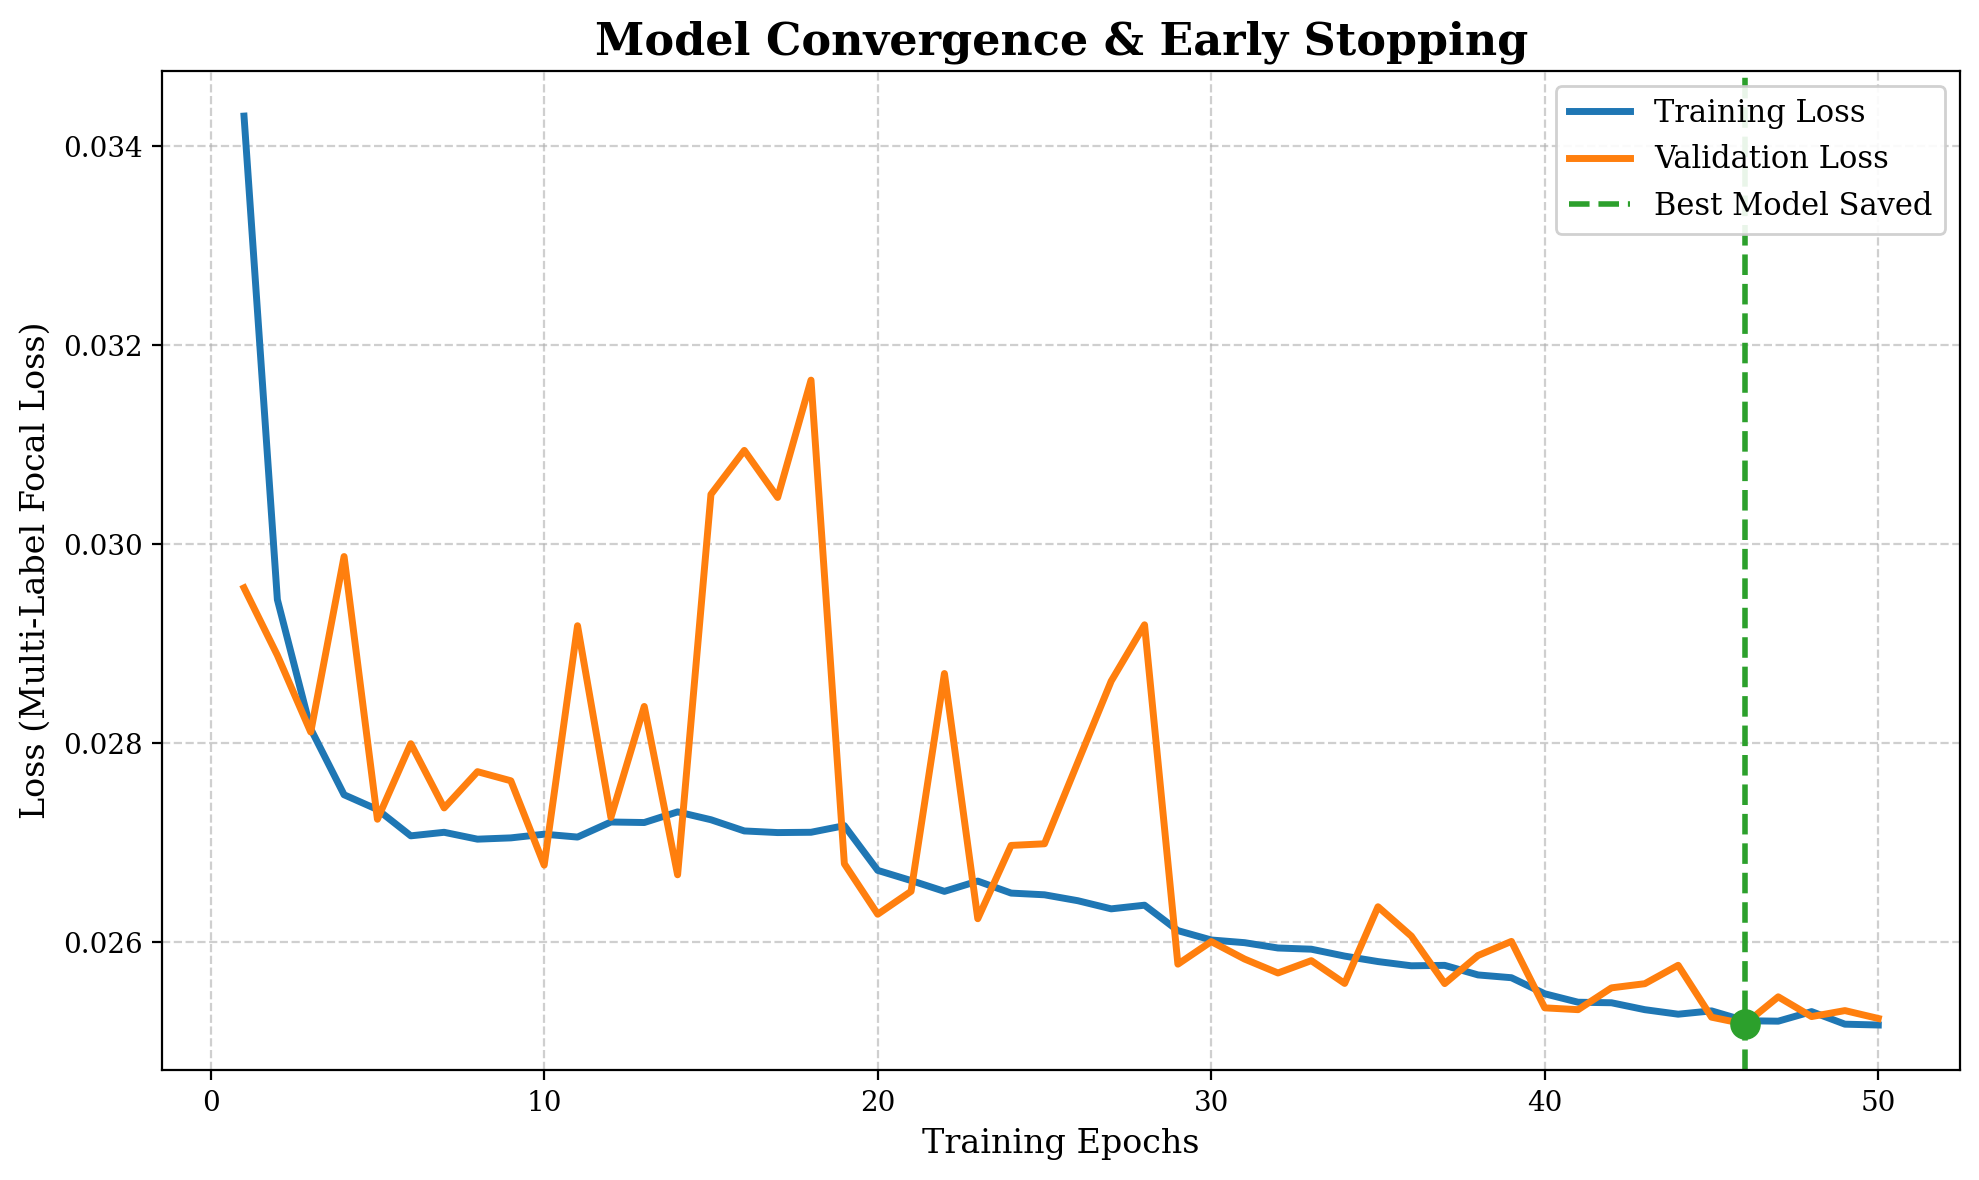

In [ ]:
visualize_learning_curve(history_train_loss, history_val_loss, best_epoch)

### Evaluation

In [ ]:
final_model.load_state_dict(torch.load(best_model_path))
final_model.eval()

val_predictions = []
val_targets = []

# 1. Get raw probabilities for the Validation Set
with torch.no_grad():
    for features, labels in val_loader:
        features, labels = features.to(device), labels.float().to(device)
        probs = torch.sigmoid(final_model(features))
        val_predictions.extend(probs.cpu().numpy())
        val_targets.extend(labels.cpu().numpy())

val_predictions = np.array(val_predictions)
val_targets = np.array(val_targets)

# 2. Search for the perfect threshold for EACH disease
optimal_thresholds = []
# 1. ADD THIS: A dictionary to store the F1 scores at every threshold step
threshold_history = {cls: [] for cls in superclasses}
threshold_range = np.arange(0.1, 0.95, 0.05)

for i in range(len(superclasses)):
    best_thresh = 0.5
    best_f1 = 0.0

    for thresh in threshold_range:
        # Binarize predictions
        preds = (val_predictions[:, i] > thresh).astype(int)

        # Calculate F1
        current_f1 = f1_score(val_targets[:, i], preds, zero_division=0)

        # Track the history for the plot
        threshold_history[superclasses[i]].append(current_f1)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh

    optimal_thresholds.append(best_thresh)
    print(f"  - {superclasses[i]}: {best_thresh:.2f} (Val F1: {best_f1:.3f})")

optimal_thresholds = np.array(optimal_thresholds)

  - NORM: 0.45 (Val F1: 0.807)
  - MI: 0.40 (Val F1: 0.580)
  - STTC: 0.45 (Val F1: 0.629)
  - CD: 0.40 (Val F1: 0.605)
  - HYP: 0.40 (Val F1: 0.392)


In [ ]:
def visualize_thresholds(threshold_range, history_dict, best_thresholds, class_names):
    plt.figure(figsize=(12, 7))

    # Distinct colors for the 5 diseases
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, class_name in enumerate(class_names):
        f1_scores = history_dict[class_name]
        best_t = best_thresholds[i]
        best_f = max(f1_scores)

        # Plot the curve
        plt.plot(threshold_range, f1_scores, color=colors[i], linewidth=2.5, alpha=0.8, label=f"{class_name}")

        # Highlight the peak with a star
        plt.scatter(best_t, best_f, color=colors[i], marker='*', s=200, zorder=5, edgecolors='black')

        # Add a subtle vertical drop-line from the peak to the x-axis
        plt.vlines(x=best_t, ymin=0, ymax=best_f, color=colors[i], linestyle=':', alpha=0.6)

    # Formatting
    plt.title("Empirical Threshold Optimization (F1-Score vs. Threshold)", fontsize=16, fontweight='bold')
    plt.xlabel("Classification Threshold", fontsize=12)
    plt.ylabel("Validation F1-Score", fontsize=12)

    # Set axis limits
    plt.xlim(0.05, 0.95)
    plt.ylim(0, 1.0)
    plt.xticks(np.arange(0.1, 1.0, 0.1))

    plt.grid(True, linestyle='--', alpha=0.5)

    # Create a clean legend
    plt.legend(title="Disease Class (Star = Optimal Thresh)", loc='lower left', fontsize=10)

    plt.tight_layout()
    plt.show()

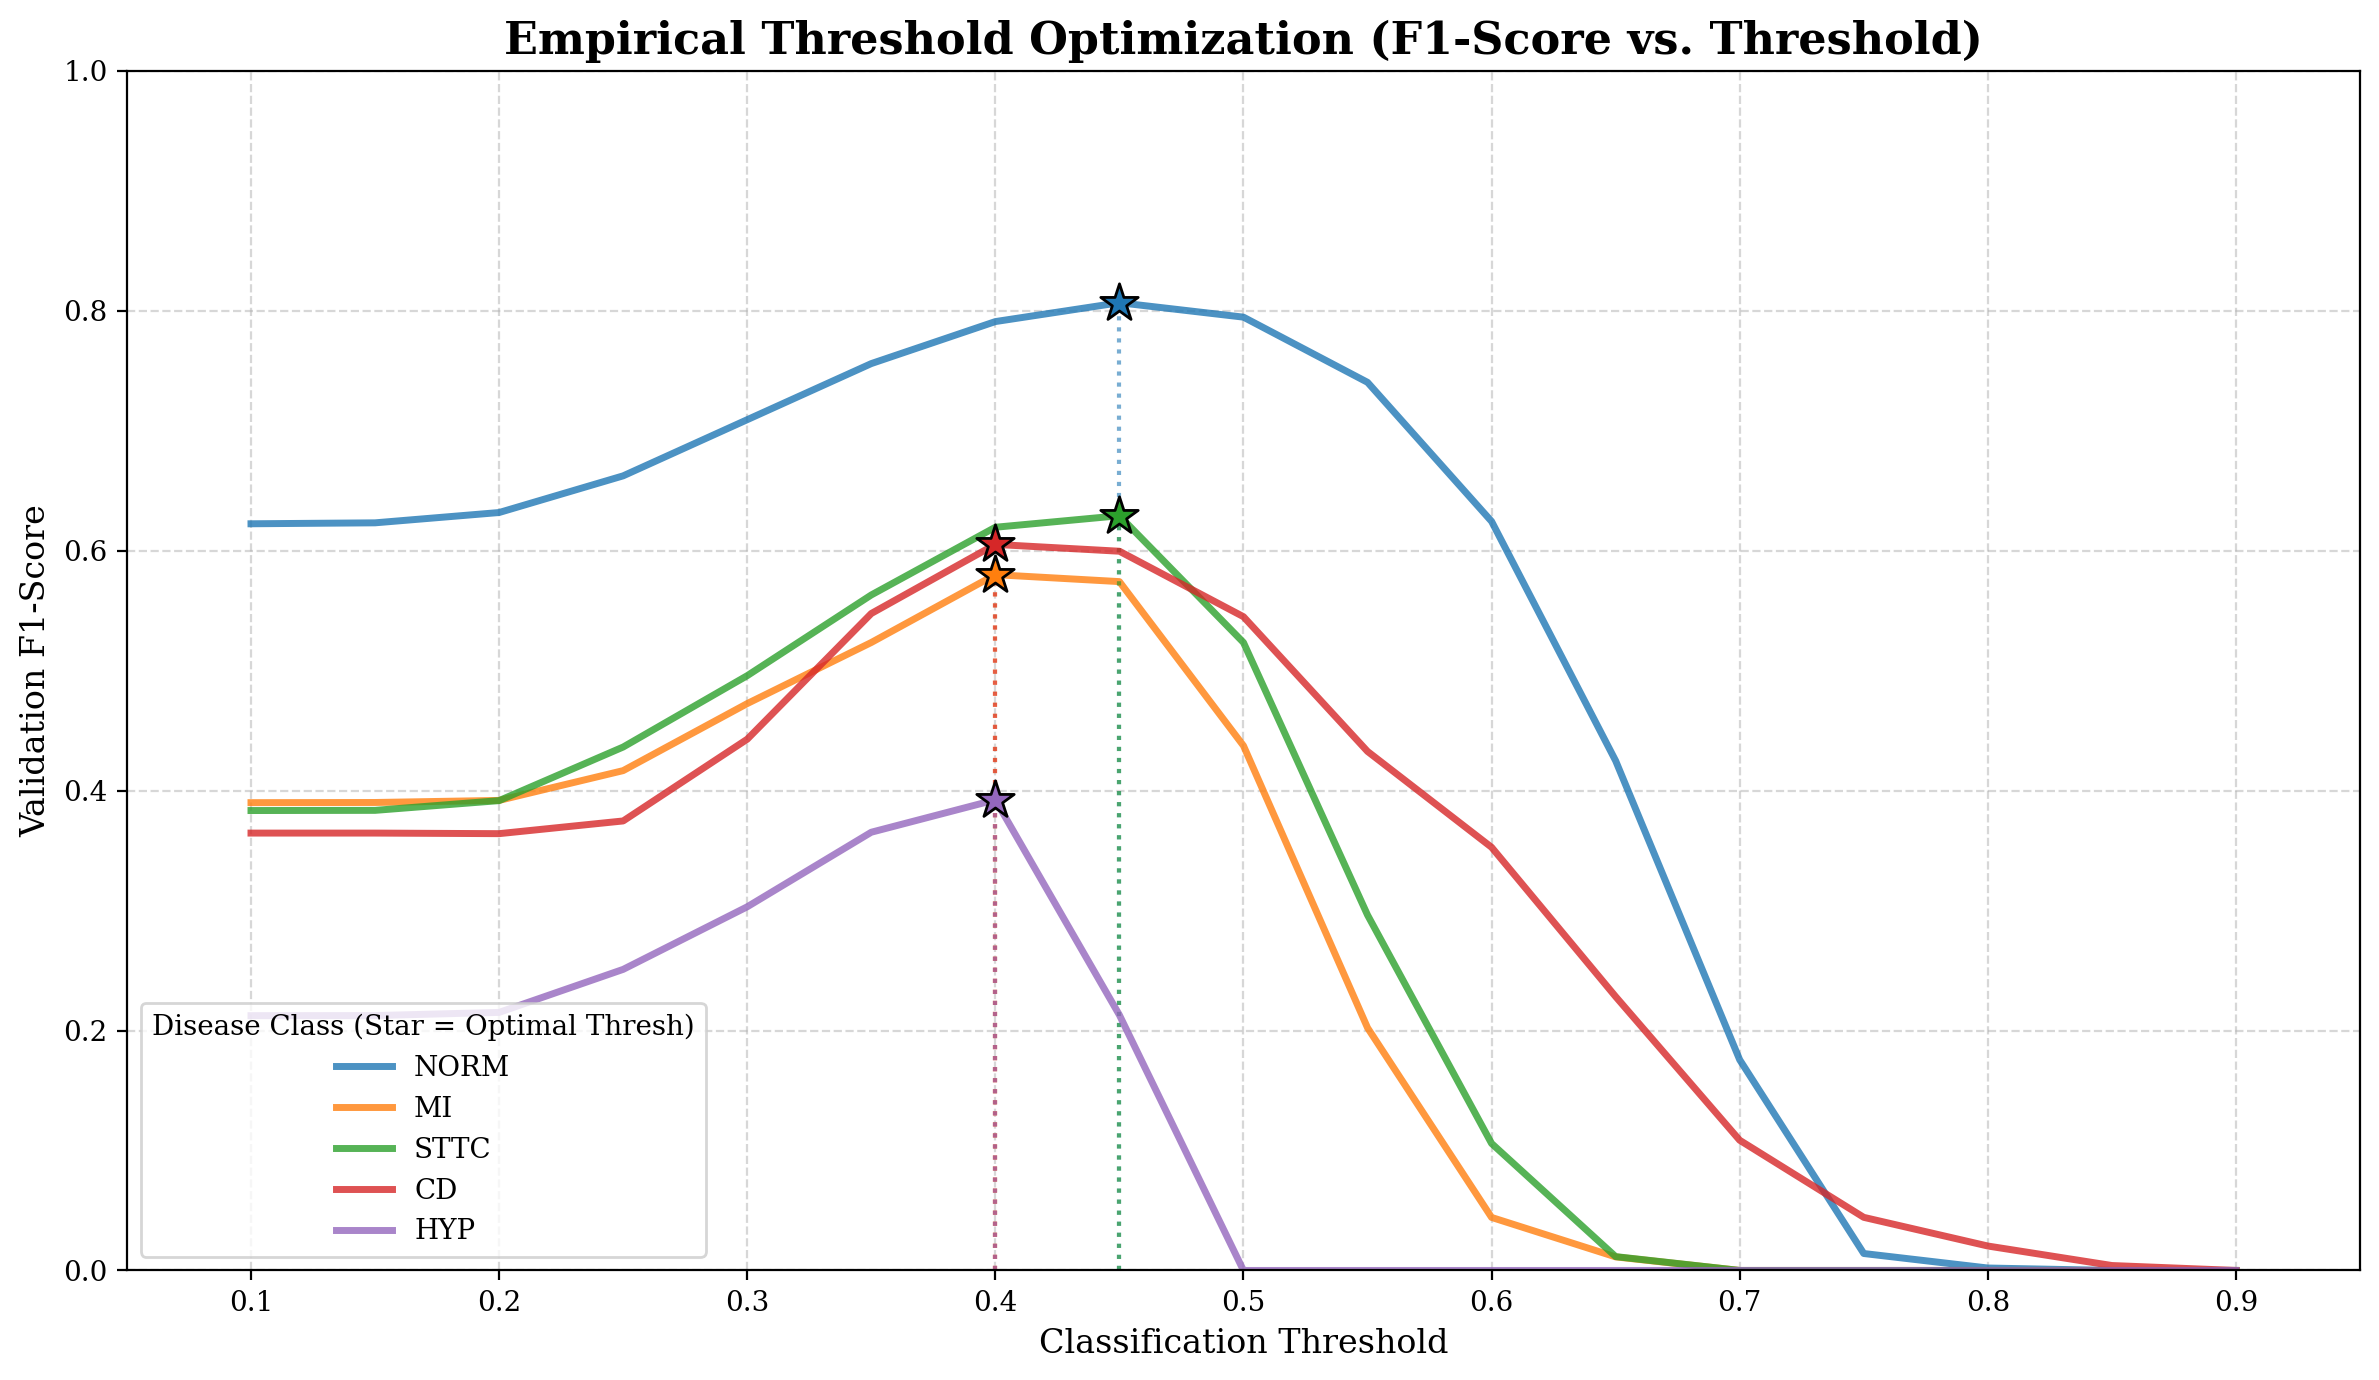

In [ ]:
visualize_thresholds(threshold_range, threshold_history, optimal_thresholds, superclasses)

In [ ]:
final_model.eval()

all_predictions = []
all_targets = []
all_probs = [] # <--- NEW: We must track raw probabilities!

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.float().to(device)

        # Get probabilities
        probs = torch.sigmoid(final_model(features)).cpu().numpy()

        # Save raw probabilities for ROC/PR curves
        all_probs.extend(probs)

        # Binarize using optimal thresholds
        predicted = (probs > optimal_thresholds).astype(float)

        all_predictions.extend(predicted)
        all_targets.extend(labels.cpu().numpy())

all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)
all_probs = np.array(all_probs)

print("\n--- Final Multi-Label Classification Report ---")
print(classification_report(all_targets, all_predictions, target_names=superclasses, zero_division=0))

# --- THE NEW CLINICAL METRICS ---
print("\n--- Advanced Clinical Area Under Curve (AUC) Metrics ---")
roc_aucs = roc_auc_score(all_targets, all_probs, average=None)
pr_aucs = average_precision_score(all_targets, all_probs, average=None)

for i, disease in enumerate(superclasses):
    print(f"{disease:^5} | ROC-AUC: {roc_aucs[i]:.3f} | PR-AUC: {pr_aucs[i]:.3f}")


--- Final Multi-Label Classification Report ---
              precision    recall  f1-score   support

        NORM       0.74      0.89      0.80       948
          MI       0.46      0.82      0.59       519
        STTC       0.58      0.62      0.60       535
          CD       0.57      0.70      0.63       527
         HYP       0.39      0.41      0.40       263

   micro avg       0.58      0.74      0.65      2792
   macro avg       0.55      0.69      0.61      2792
weighted avg       0.59      0.74      0.65      2792
 samples avg       0.64      0.74      0.67      2792


--- Advanced Clinical Area Under Curve (AUC) Metrics ---
NORM  | ROC-AUC: 0.898 | PR-AUC: 0.858
 MI   | ROC-AUC: 0.839 | PR-AUC: 0.638
STTC  | ROC-AUC: 0.846 | PR-AUC: 0.649
 CD   | ROC-AUC: 0.838 | PR-AUC: 0.676
 HYP  | ROC-AUC: 0.764 | PR-AUC: 0.358


In [ ]:
def visualize_roc_curves(targets, probs, class_names):
    plt.figure(figsize=(10, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, class_name in enumerate(class_names):
        # Calculate False Positive Rate and True Positive Rate
        fpr, tpr, _ = roc_curve(targets[:, i], probs[:, i])
        auc_score = roc_auc_score(targets[:, i], probs[:, i])

        plt.plot(fpr, tpr, color=colors[i], linewidth=2,
                 label=f"{class_name} (AUC = {auc_score:.3f})")

    # Plot the random guess diagonal
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Guess (AUC = 0.500)')

    plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=16, fontweight='bold')
    plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
    plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="lower right", fontsize=11)

    plt.tight_layout()
    plt.show()

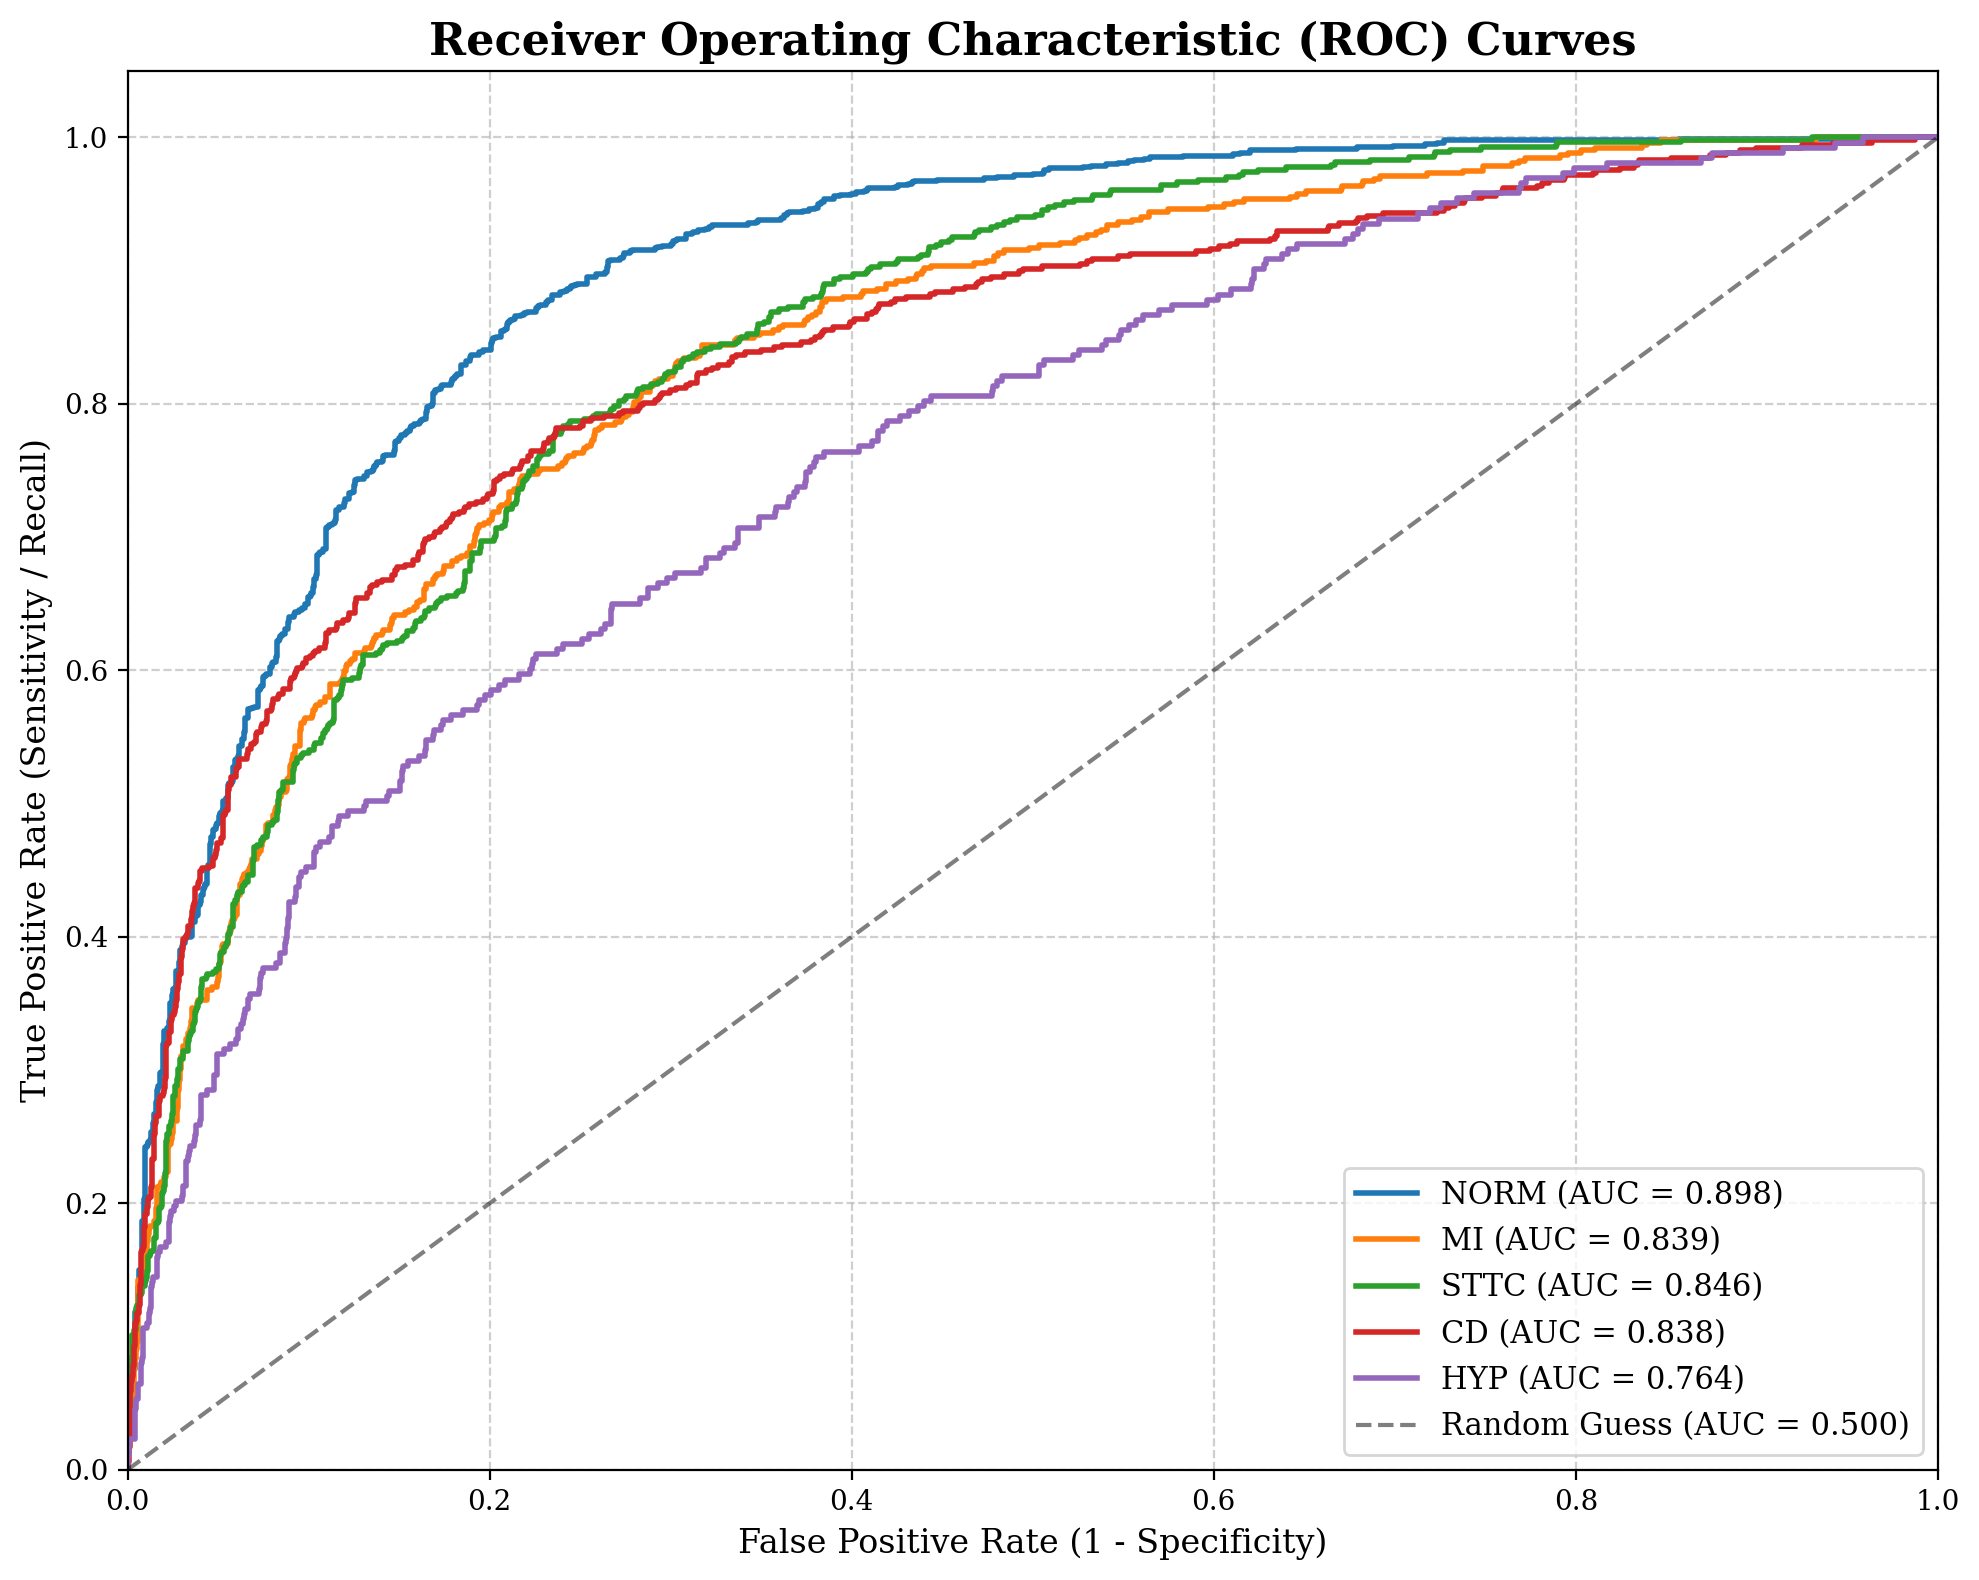

In [ ]:
visualize_roc_curves(all_targets, all_probs, superclasses)

In [ ]:
def visualize_clinical_confusion_matrices(targets, predictions, class_names):
    mcm = multilabel_confusion_matrix(targets, predictions)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle("Clinical Confusion Matrices per Disease (Threshold Applied)", fontsize=16, fontweight='bold', y=1.05)

    for i, ax in enumerate(axes):
        tn, fp, fn, tp = mcm[i].ravel()
        matrix = np.array([[tn, fp], [fn, tp]])

        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Predicted Negative', 'Predicted Positive'],
                    yticklabels=['Actual Negative', 'Actual Positive'], ax=ax,
                    annot_kws={"size": 14, "weight": "bold"})

        ax.set_title(f"Class: {class_names[i]}", fontsize=14)

        recall = tp / (tp + fn + 1e-8)
        precision = tp / (tp + fp + 1e-8)
        ax.set_xlabel(f"\nRecall: {recall:.2f} | Precision: {precision:.2f}", fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()


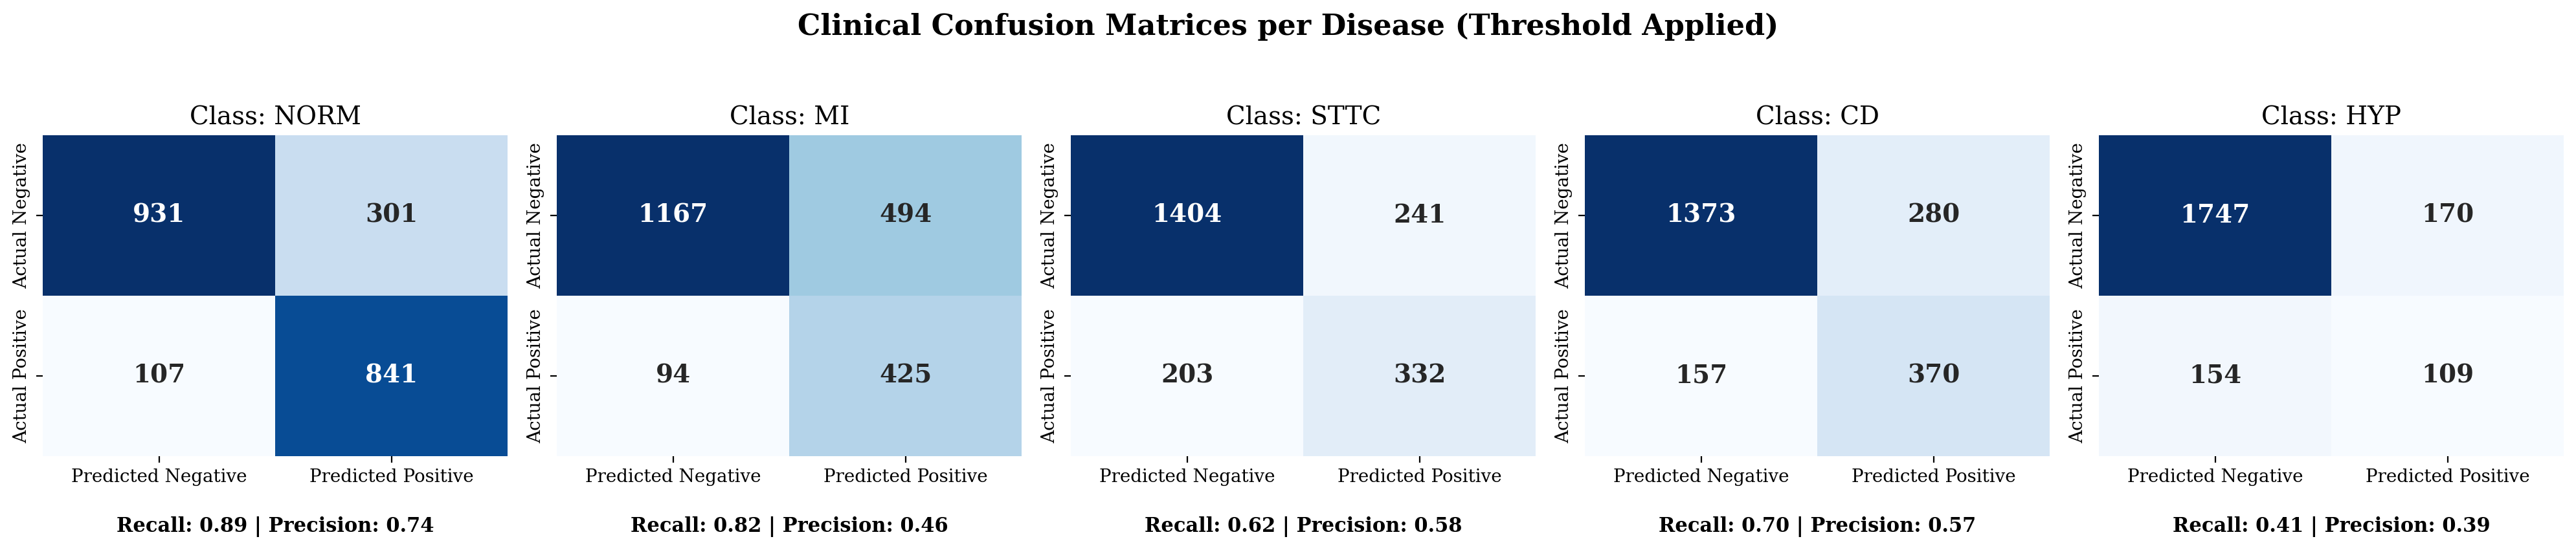

In [ ]:
visualize_clinical_confusion_matrices(all_targets, all_predictions, superclasses)

### save the model

In [ ]:
model_save_path = os.path.join(path, f'ACO_FCN_with_val_loss_{epoch_val_loss:.4f}.pth')
torch.save(final_model.state_dict(), model_save_path)
print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: /content/drive/Shareddrives/XAI Project Shared Drive/ACO_FCN_with_val_loss_0.0252.pth


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define best_hparams with the values that match the saved model
best_hparams = {'num_filters': 8, 'kernel_size': 3, 'dense_units': 64, 'dropout_rate': 0.6, 'lr': 0.0005}

# Re-initialize the model using best_hparams and input_feature_size
input_feature_size = X_train.shape[1] # X_train is available in kernel state
final_model = FCN(
    input_features=input_feature_size,
    num_filters=best_hparams['num_filters'],
    kernel_size=best_hparams['kernel_size'],
    dense_units=best_hparams['dense_units'],
    dropout_rate=best_hparams['dropout_rate'],
).to(device)

model_load_path = os.path.join(path, 'ACO_FCN_with_val_loss_0.0252.pth')
final_model.load_state_dict(torch.load(model_load_path, map_location=device))
print(f"Model loaded successfully from: {model_load_path}")

Model loaded successfully from: /content/drive/Shareddrives/XAI Project Shared Drive/ACO_FCN_with_val_loss_0.0252.pth


### SHAP

In [27]:
def generate_real_feature_names(num_leads=12, swt_level=3):
    """
    Reverse-engineers the ECGFeatureExtractor to generate human-readable names.
    """
    lead_names = ['Lead I', 'Lead II', 'Lead III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    metrics = ['Amplitude', 'Frequency']
    stats = ['Mean', 'Std_Dev', 'Skewness', 'Kurtosis']

    levels = [f"SWT_L{i}" for i in range(swt_level, 0, -1)]

    feature_names = []

    for lead in range(num_leads):
        for level in levels:
            for metric in metrics:
                for stat in stats:
                    name = f"{lead_names[lead]} | {level} | {metric[:4]} | {stat}"
                    feature_names.append(name)

    return feature_names

In [28]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

final_model.eval()
print("\n--- Initializing SHAP DeepExplainer ---")

background_features = []
for features, _ in train_loader:
    background_features.append(features)
    if len(background_features) * batch_size >= 150:
        break
background_tensor = torch.cat(background_features)[:150].to(device)

explainer = shap.DeepExplainer(final_model, background_tensor)

#get test batches
test_features, test_labels = next(iter(test_loader))
test_features = test_features.to(device)
test_labels = test_labels.cpu().numpy()

print("Calculating SHAP values for the test batch (This may take a minute)...")
shap_values = explainer.shap_values(test_features)

num_actual_features = test_features.view(test_features.size(0), -1).shape[1]
feature_names_list = generate_real_feature_names(num_leads=12, swt_level=3)

DISEASE_INDEX = 1 # 1 = MI (Myocardial Infarction)
PATIENT_INDEX = 0

#clean the test features into a 2D array
target_test_features = test_features.cpu().numpy().reshape(test_features.shape[0], -1)

shap_values_np = np.array(shap_values)
num_classes = len(superclasses)

target_shap_values = shap_values_np[:, :, DISEASE_INDEX].reshape(test_features.shape[0], -1)

print(f"Verified Array Shapes -> SHAP: {target_shap_values.shape} | Features: {target_test_features.shape}")



--- Initializing SHAP DeepExplainer ---
Calculating SHAP values for the test batch (This may take a minute)...
Verified Array Shapes -> SHAP: (64, 288) | Features: (64, 288)



--- Local Explanation: Patient 0 for Disease: MI ---


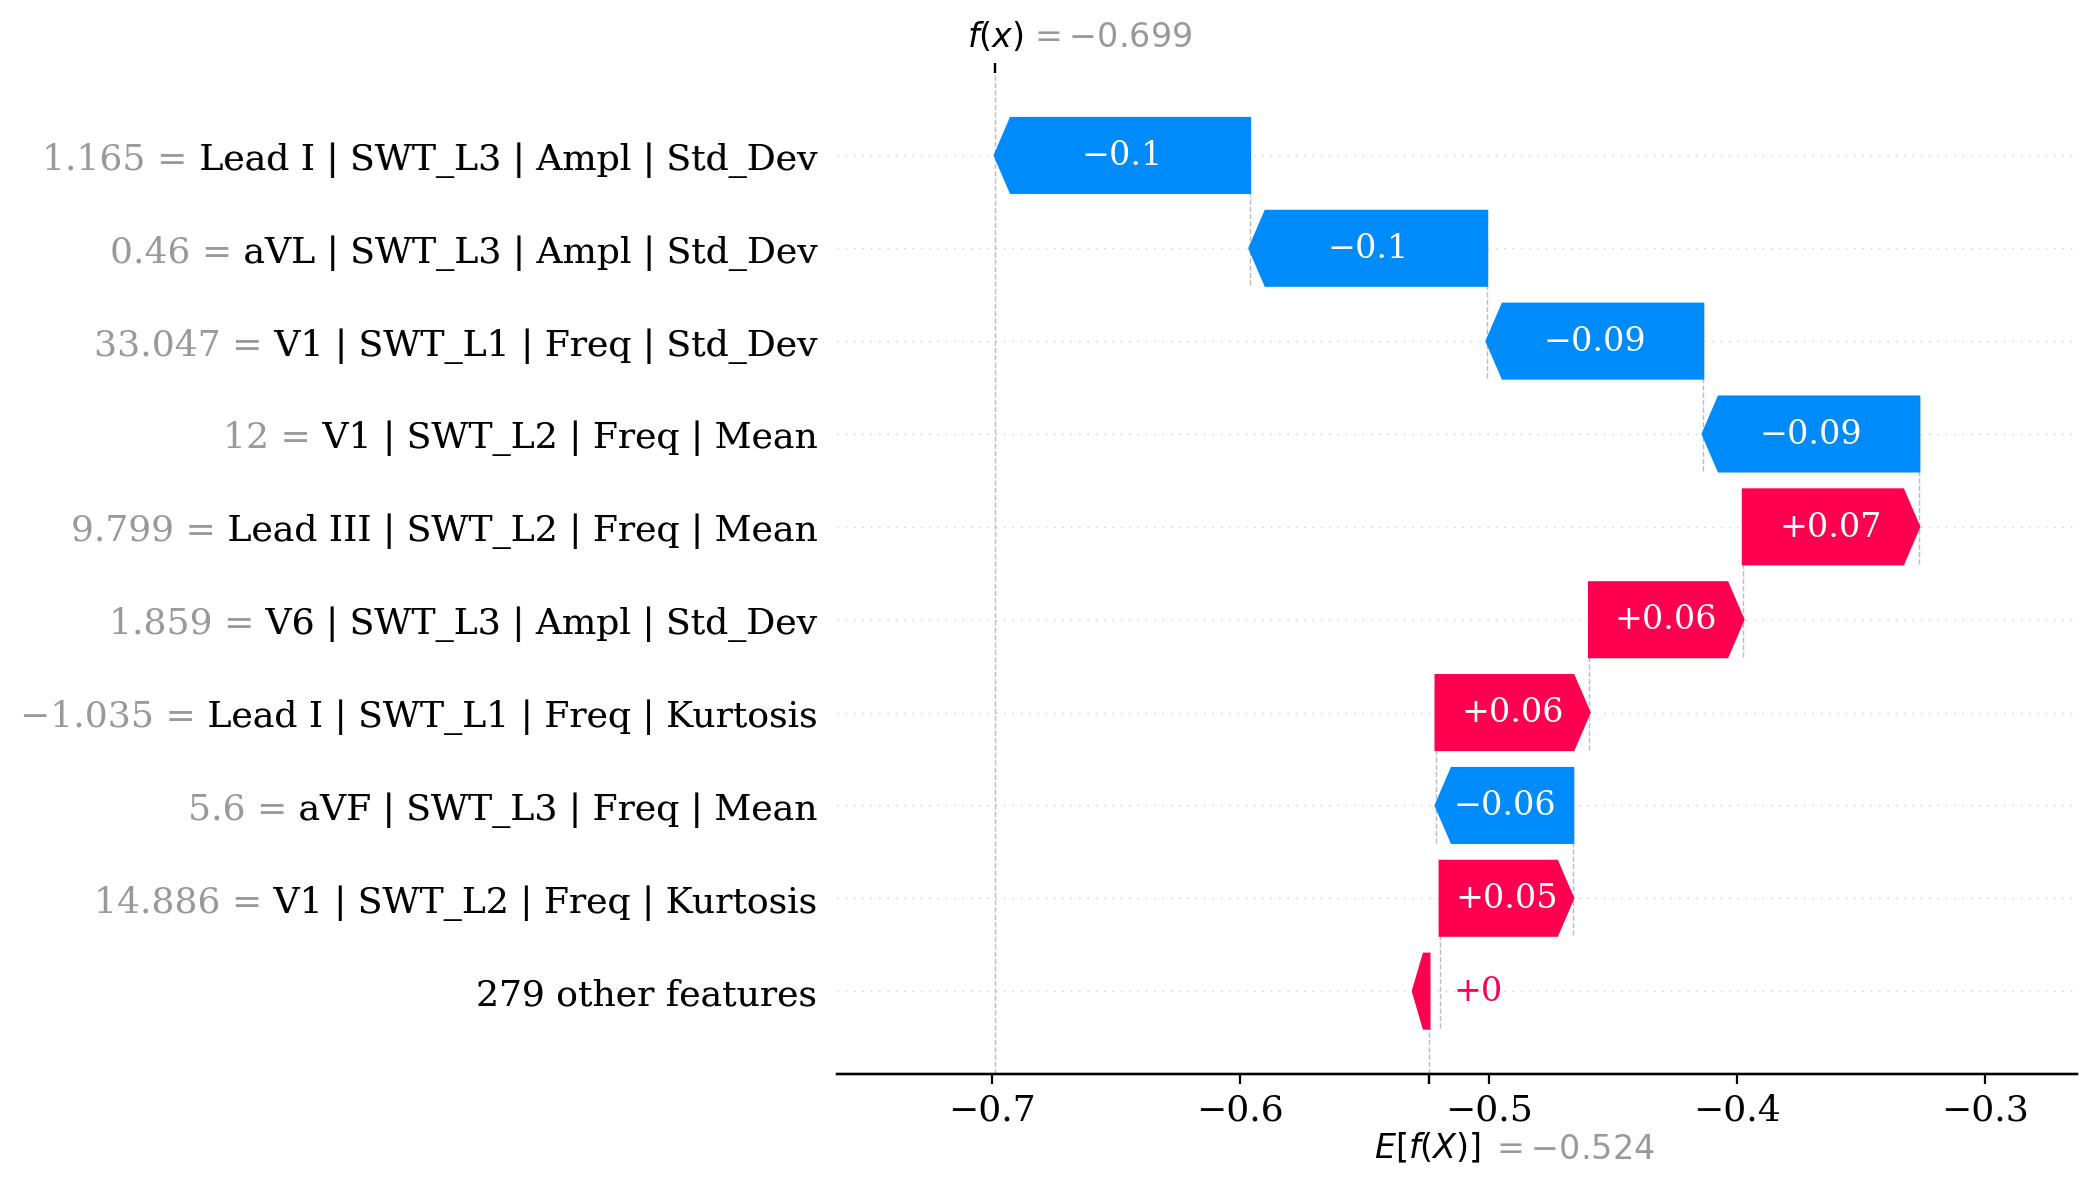

In [29]:
print(f"\n--- Local Explanation: Patient {PATIENT_INDEX} for Disease: {superclasses[DISEASE_INDEX]} ---")

patient_shap_values = target_shap_values[PATIENT_INDEX]
patient_base_value = explainer.expected_value

if isinstance(patient_base_value, list) or isinstance(patient_base_value, np.ndarray):
    if len(patient_base_value) == len(superclasses):
        patient_base_value = patient_base_value[DISEASE_INDEX]
    else:
        patient_base_value = patient_base_value[0]

patient_feature_data = target_test_features[PATIENT_INDEX]

explanation = shap.Explanation(
    values=patient_shap_values,
    base_values=patient_base_value,
    data=patient_feature_data,
    feature_names=feature_names_list
)

shap.plots.waterfall(explanation, max_display=10)
plt.show()


--- Global Explanation: Overall feature impact for MI ---


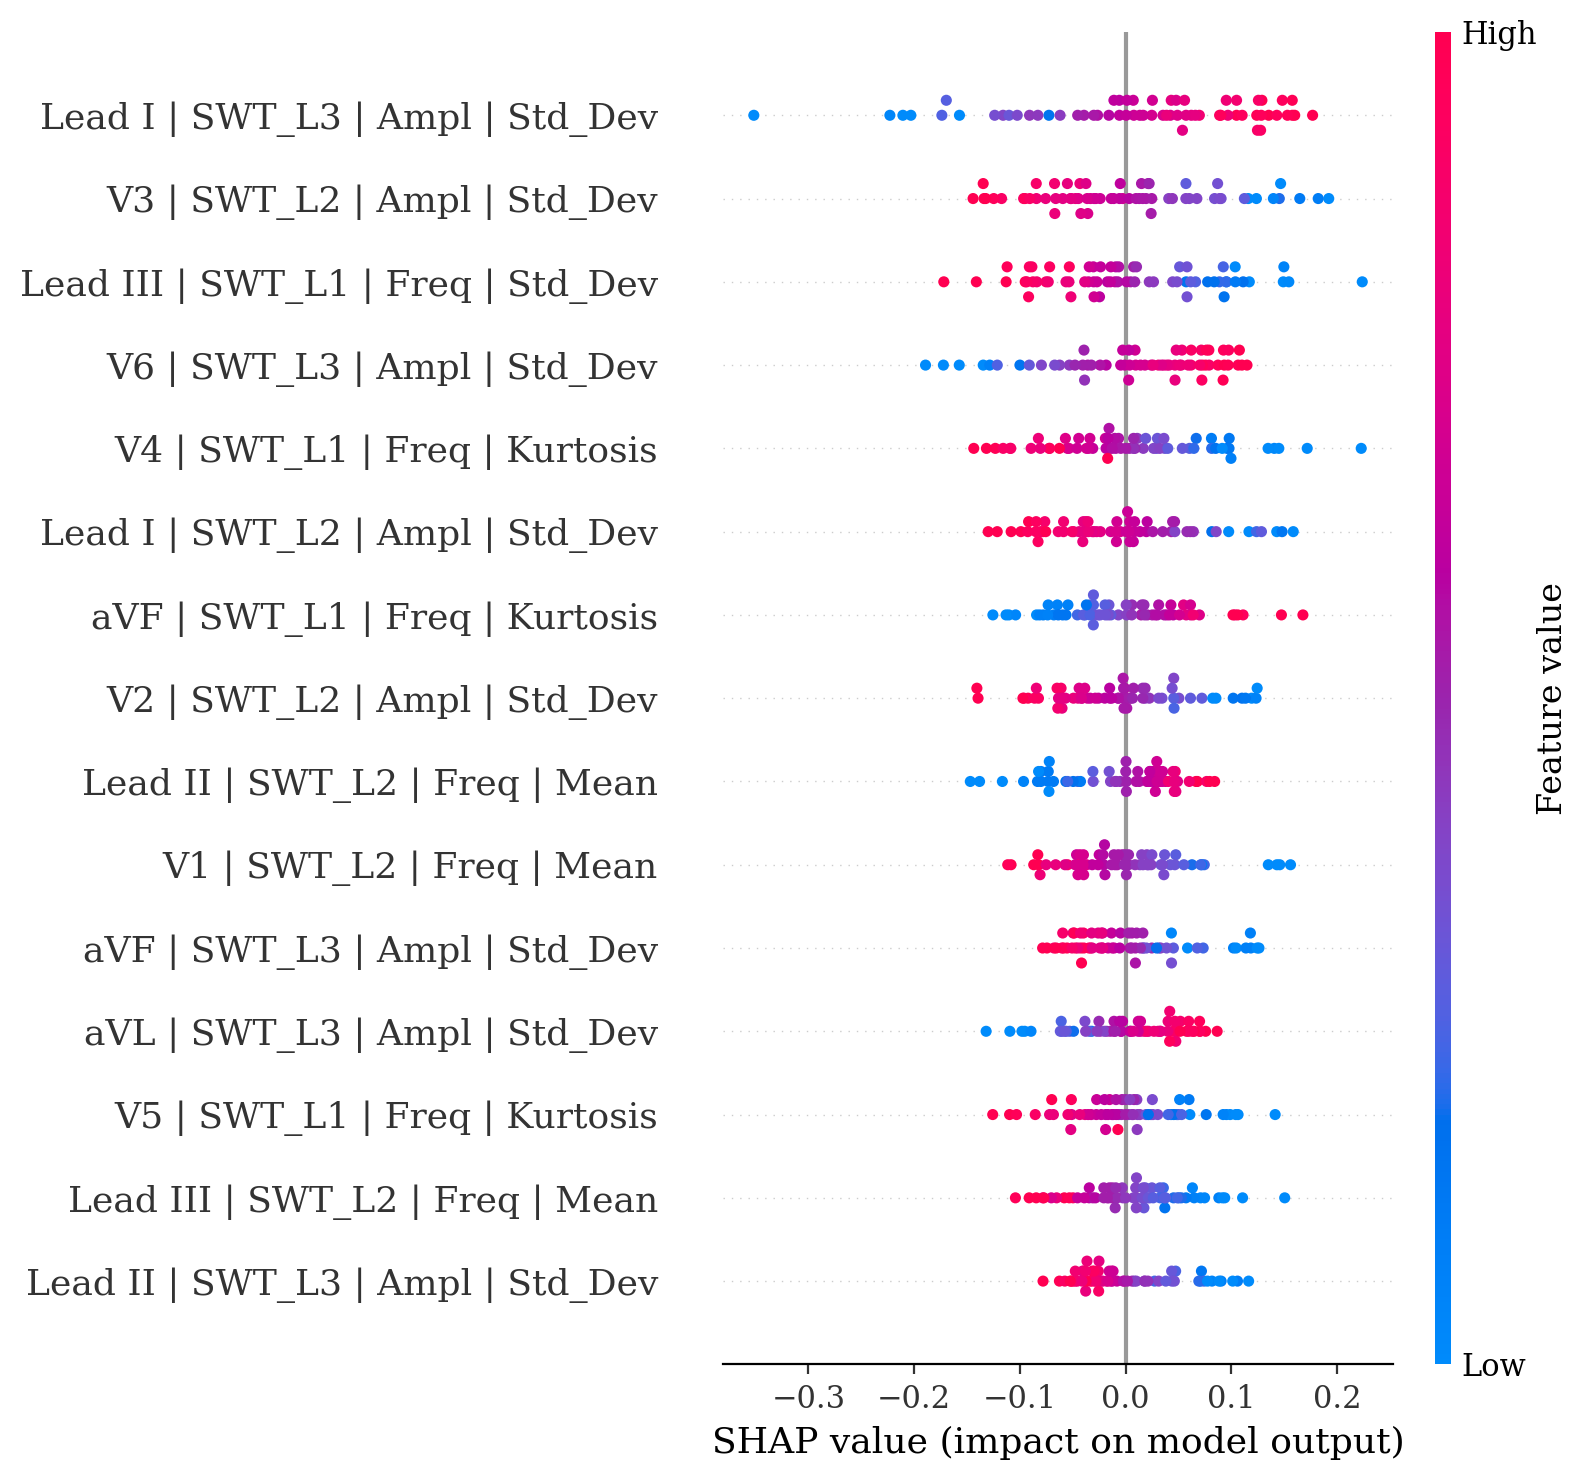

In [30]:
print(f"\n--- Global Explanation: Overall feature impact for {superclasses[DISEASE_INDEX]} ---")

shap.summary_plot(
    target_shap_values,
    features=target_test_features,
    feature_names=feature_names_list,
    max_display=15
)

In [31]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 20.5 MB/s eta 0:00:00


In [35]:
import torch

from captum.attr import IntegratedGradients, DeepLift, Saliency, NoiseTunnel
import matplotlib.pyplot as plt
model = final_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

input_tensor = test_features[PATIENT_INDEX].unsqueeze(0).to(device)
target_class = 0  # The index of the pathology you want to explain

ig = IntegratedGradients(model)
dl = DeepLift(model)
saliency = Saliency(model) # Base for SmoothGrad
nt = NoiseTunnel(saliency)

# Integrated Gradients
attr_ig = ig.attribute(input_tensor, target=target_class)

# DeepLIFT
attr_dl = dl.attribute(input_tensor, target=target_class)

# SmoothGrad
attr_sg = nt.attribute(input_tensor,
                       nt_type='smoothgrad',
                       nt_samples=20,
                       stdevs=0.2,
                       target=target_class)

# 4. Prepare for Visualization
attr_ig_val = attr_ig.squeeze().cpu().detach().numpy()
attr_dl_val = attr_dl.squeeze().cpu().detach().numpy()
attr_sg_val = attr_sg.squeeze().cpu().detach().numpy()

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_feature_names(num_leads=12, swt_level=3):
    stats = ['Mean', 'Std', 'Skew', 'Kurtosis']
    domains = ['Amp', 'Freq']
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    feature_names = []
    for lead in lead_names[:num_leads]:
        for level in range(1, swt_level + 1):
            for dom in domains:
                for stat in stats:
                    feature_names.append(f"{lead}_L{level}_{dom}_{stat}")
    return feature_names

feature_labels = get_feature_names(num_leads=12, swt_level=3)

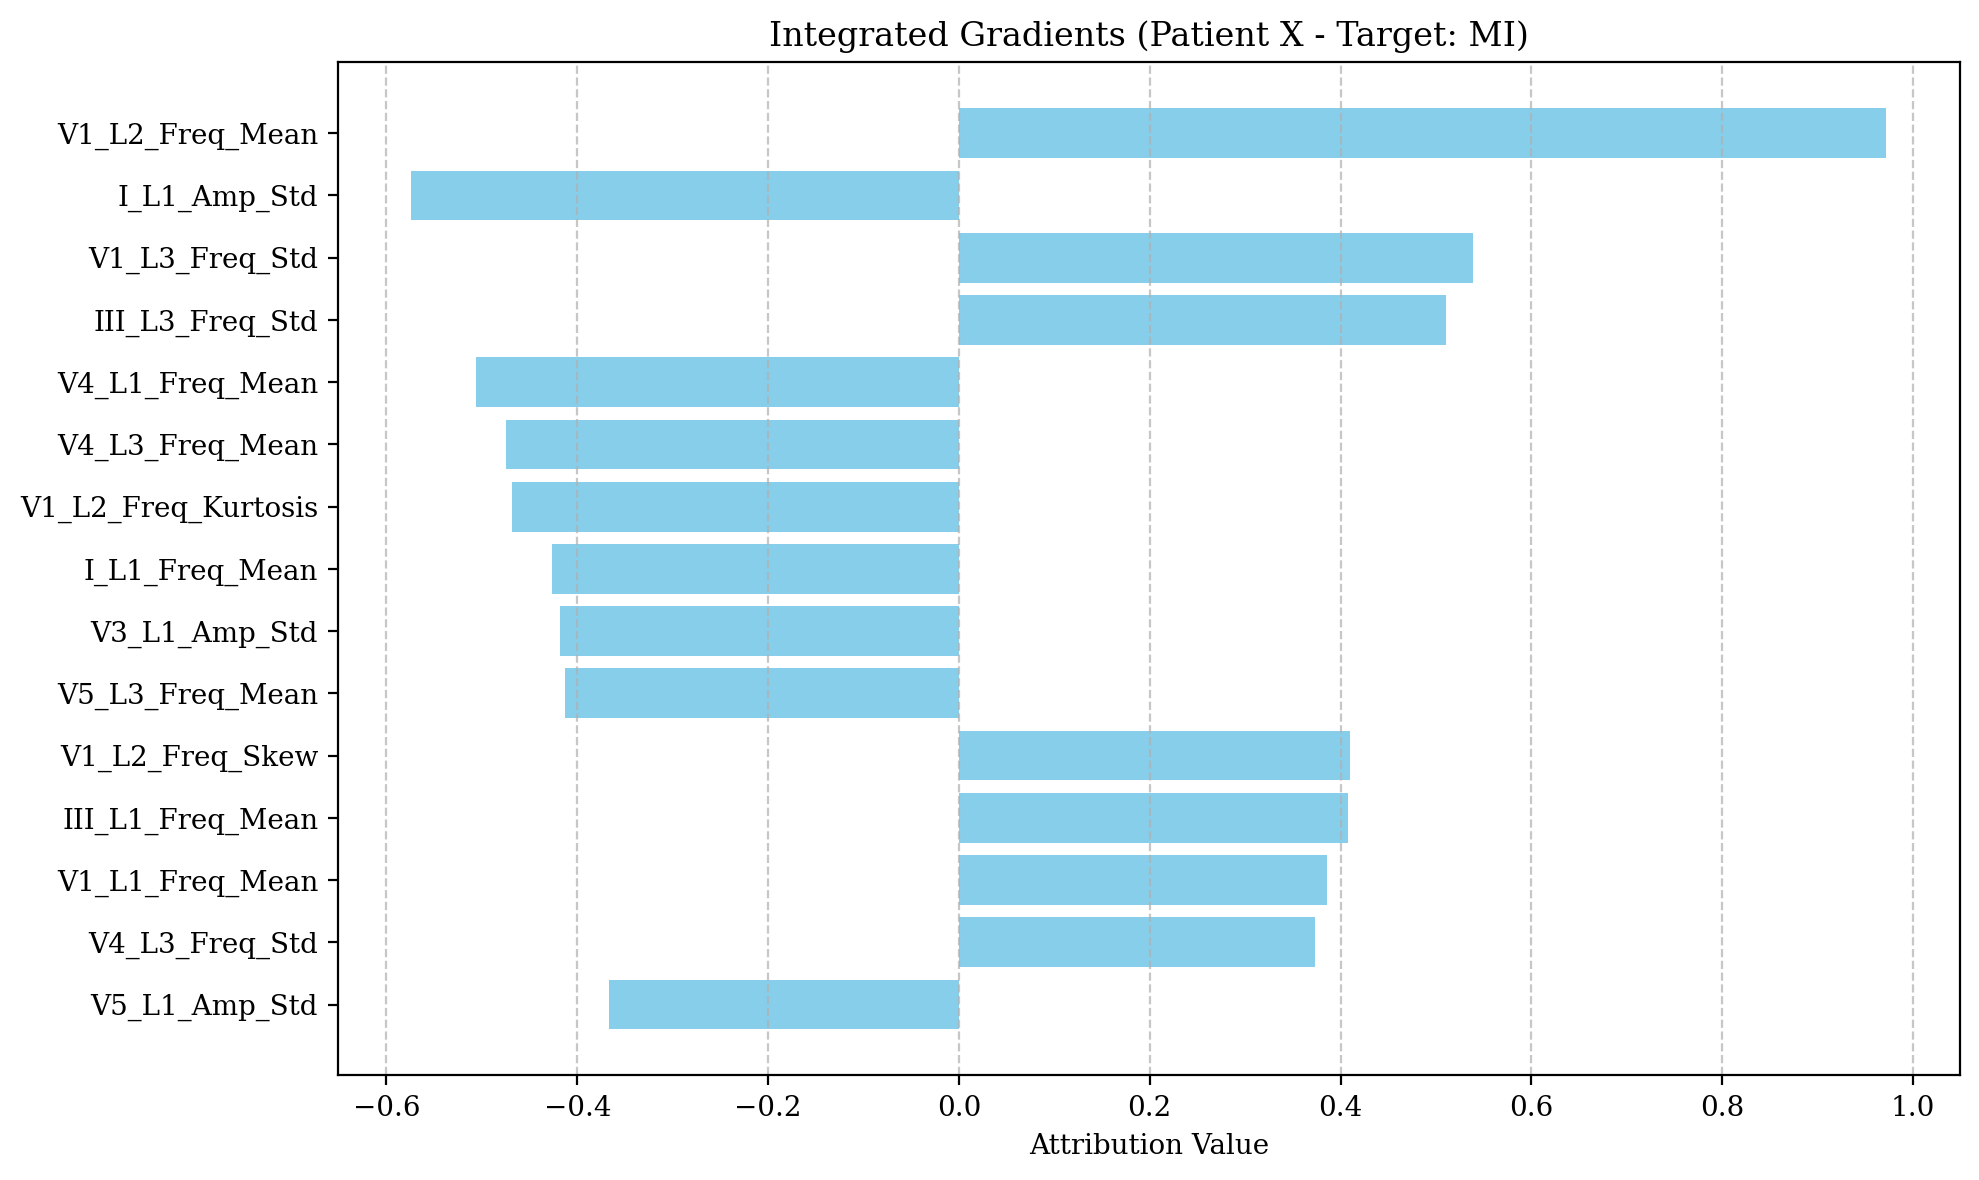

In [37]:
def plot_top_attributions(attributions, feature_names, title="Top Important Features", top_k=15):
    top_indices = np.argsort(np.abs(attributions))[-top_k:]

    plt.figure(figsize=(10, 6))
    plt.barh([feature_names[i] for i in top_indices], attributions[top_indices], color='skyblue')
    plt.xlabel("Attribution Value")
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_top_attributions(attr_ig_val, feature_labels, title="Integrated Gradients (Patient X - Target: MI)")

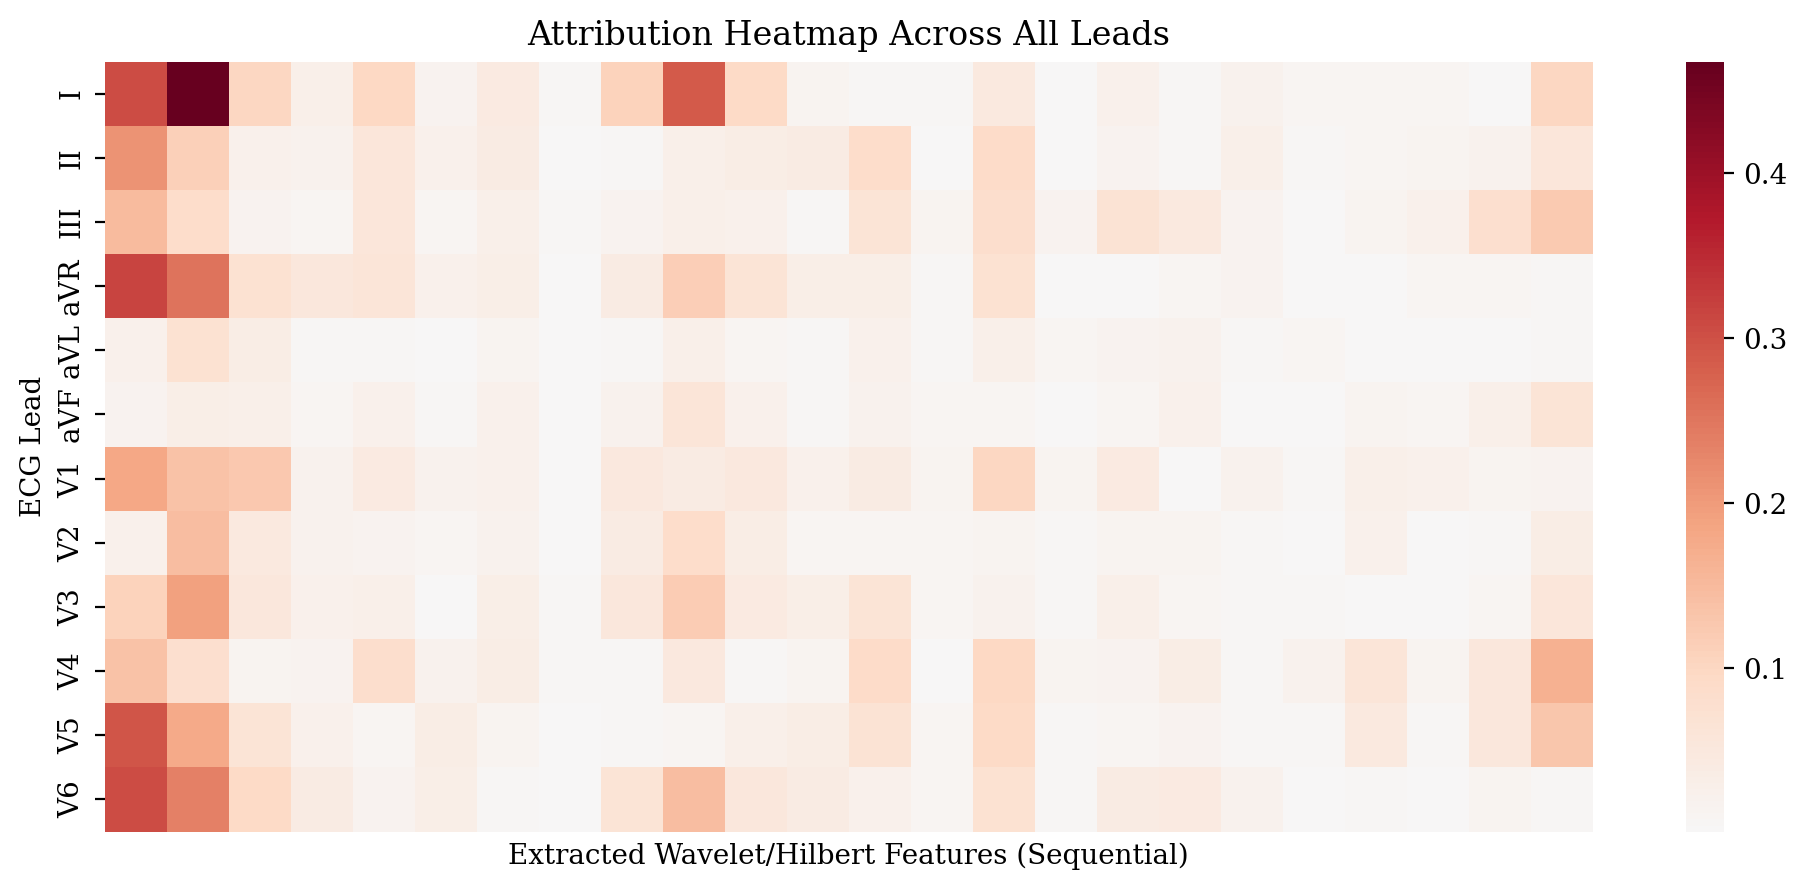

In [39]:
def plot_lead_heatmap(attributions, num_leads=12):
    features_per_lead = len(attributions) // num_leads
    attr_reshaped = attributions.reshape(num_leads, features_per_lead)

    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    plt.figure(figsize=(12, 5))
    sns.heatmap(attr_reshaped, cmap="RdBu_r", center=0,
                yticklabels=lead_names, xticklabels=False)
    plt.title("Attribution Heatmap Across All Leads")
    plt.ylabel("ECG Lead")
    plt.xlabel("Extracted Wavelet/Hilbert Features (Sequential)")
    plt.show()

plot_lead_heatmap(attr_sg_val)

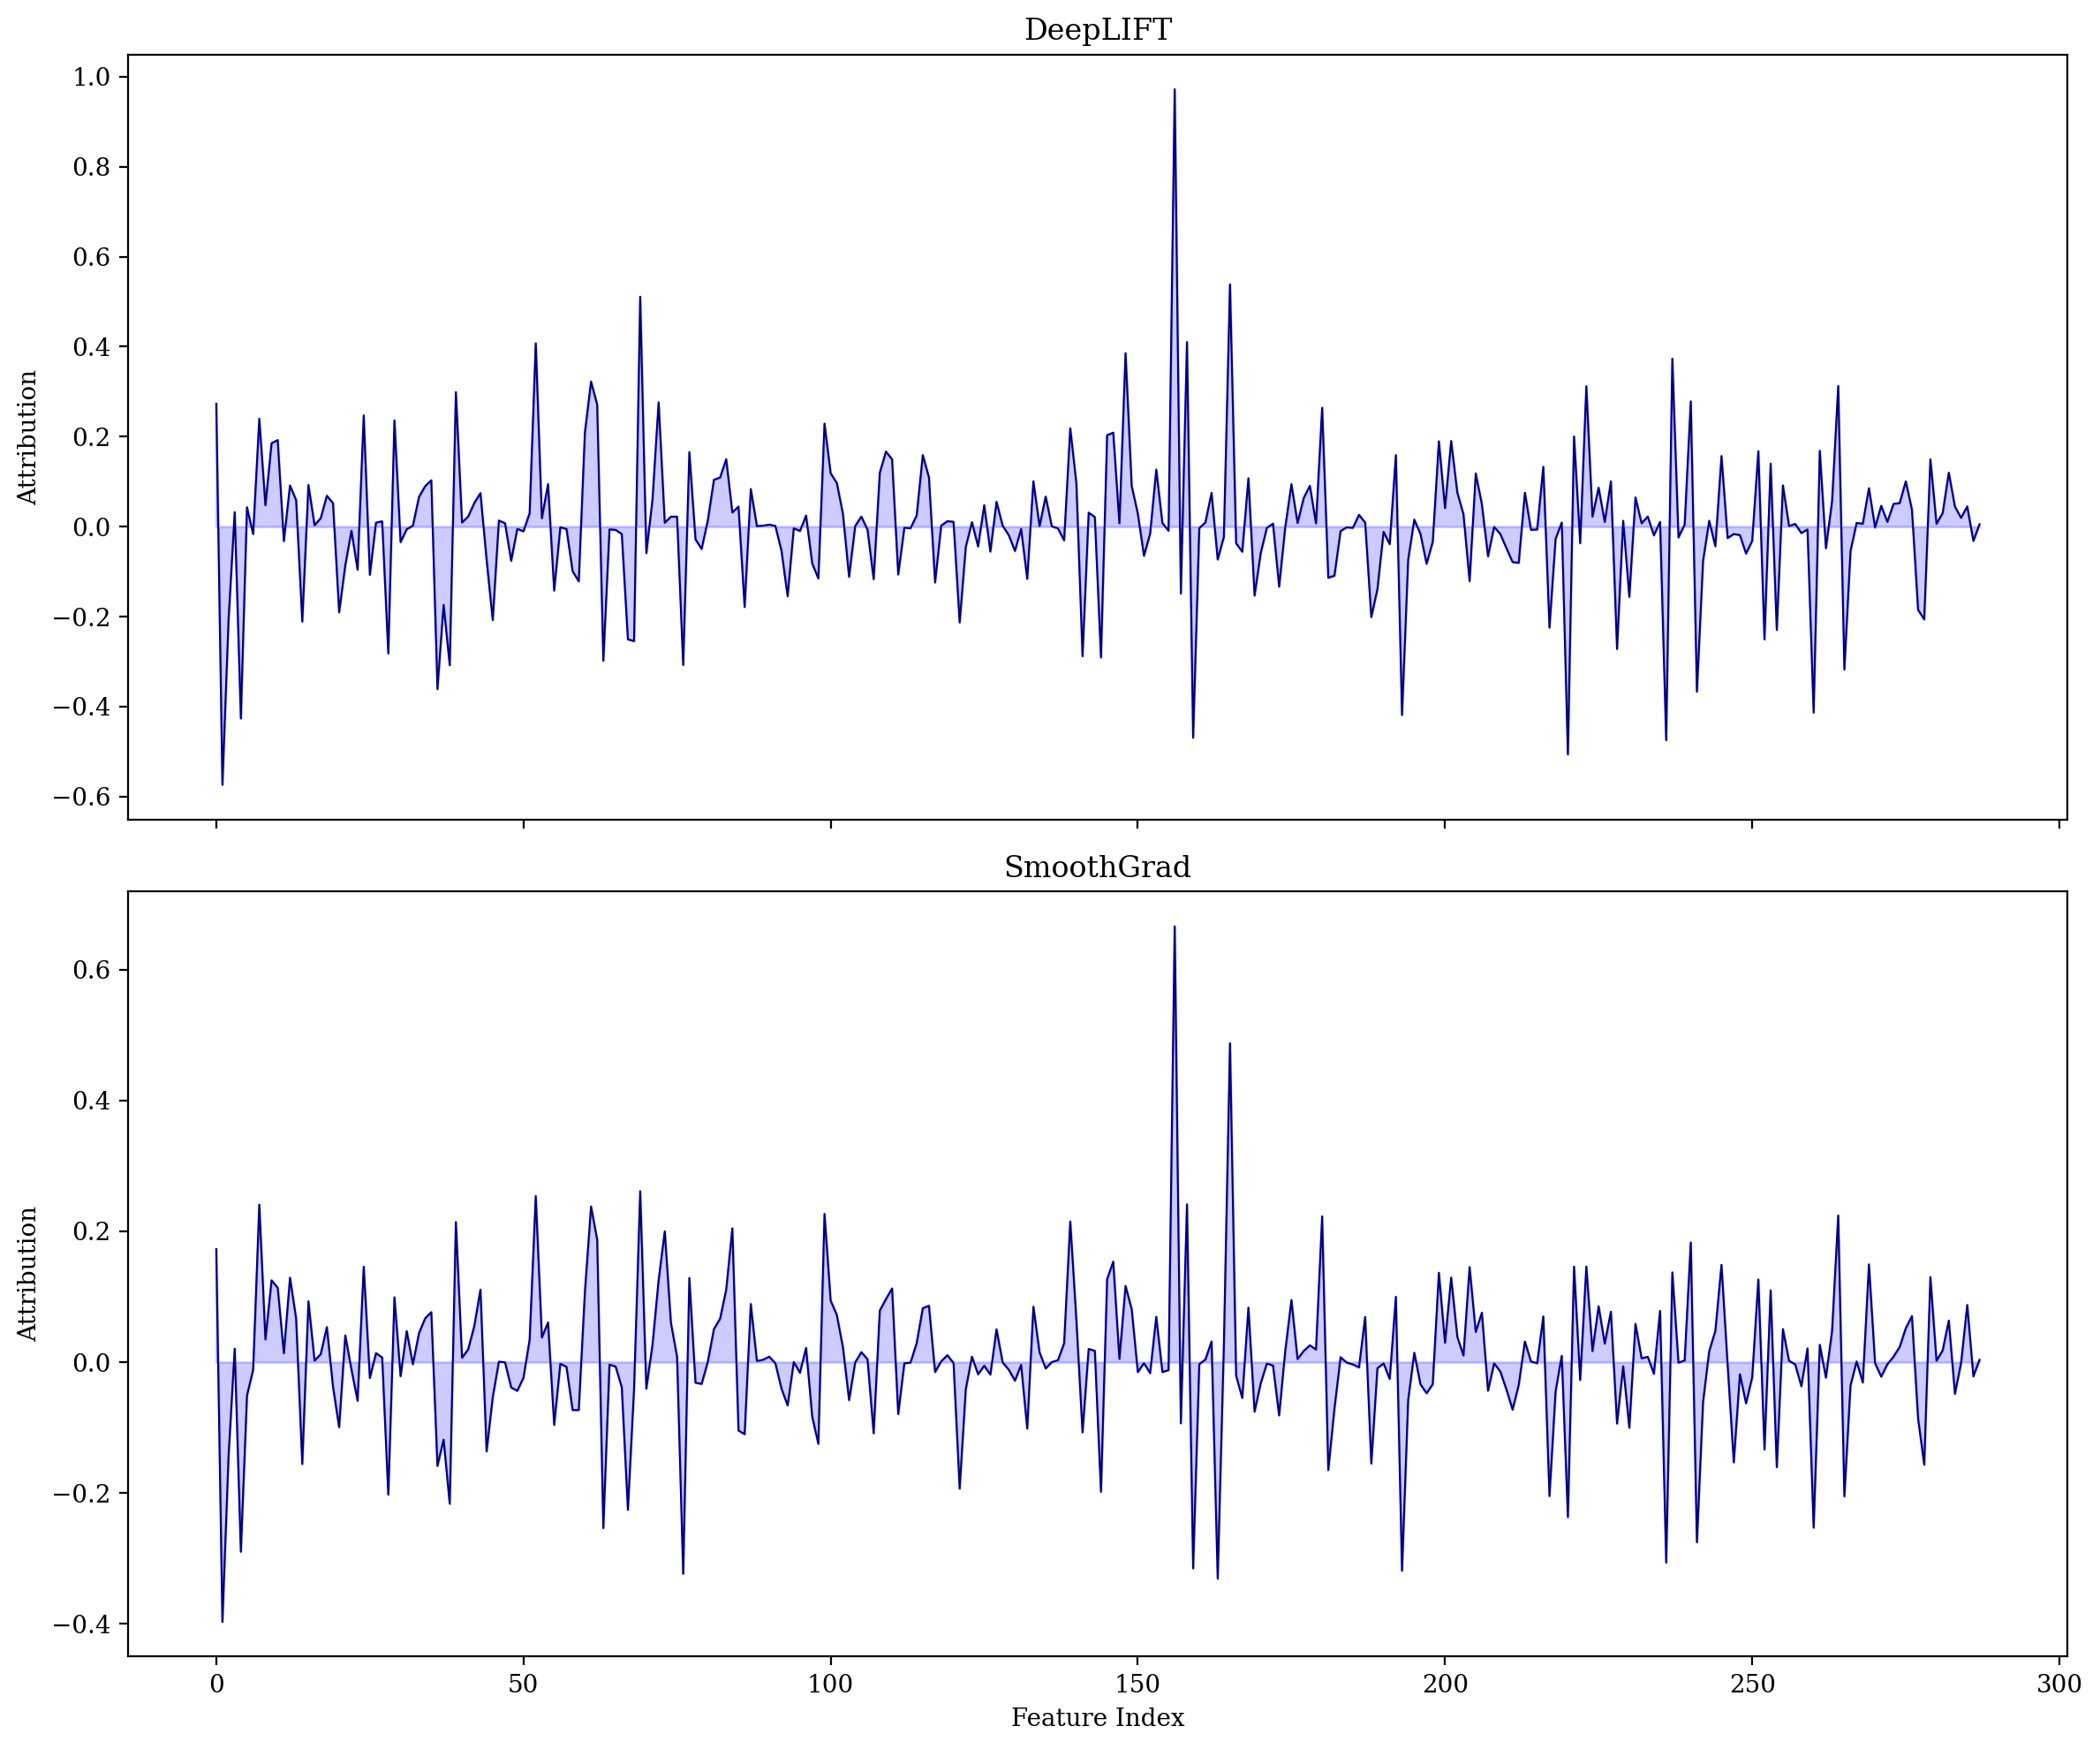

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

methods = [attr_ig_val, attr_dl_val, attr_sg_val]
names = [ "DeepLIFT", "SmoothGrad"]

for i, (attr, name) in enumerate(zip(methods, names)):
    axes[i].plot(attr, color='navy', linewidth=0.8)
    axes[i].set_title(name)
    axes[i].fill_between(range(len(attr)), attr, color='blue', alpha=0.2)
    axes[i].set_ylabel("Attribution")

plt.xlabel("Feature Index")
plt.tight_layout()
plt.show()

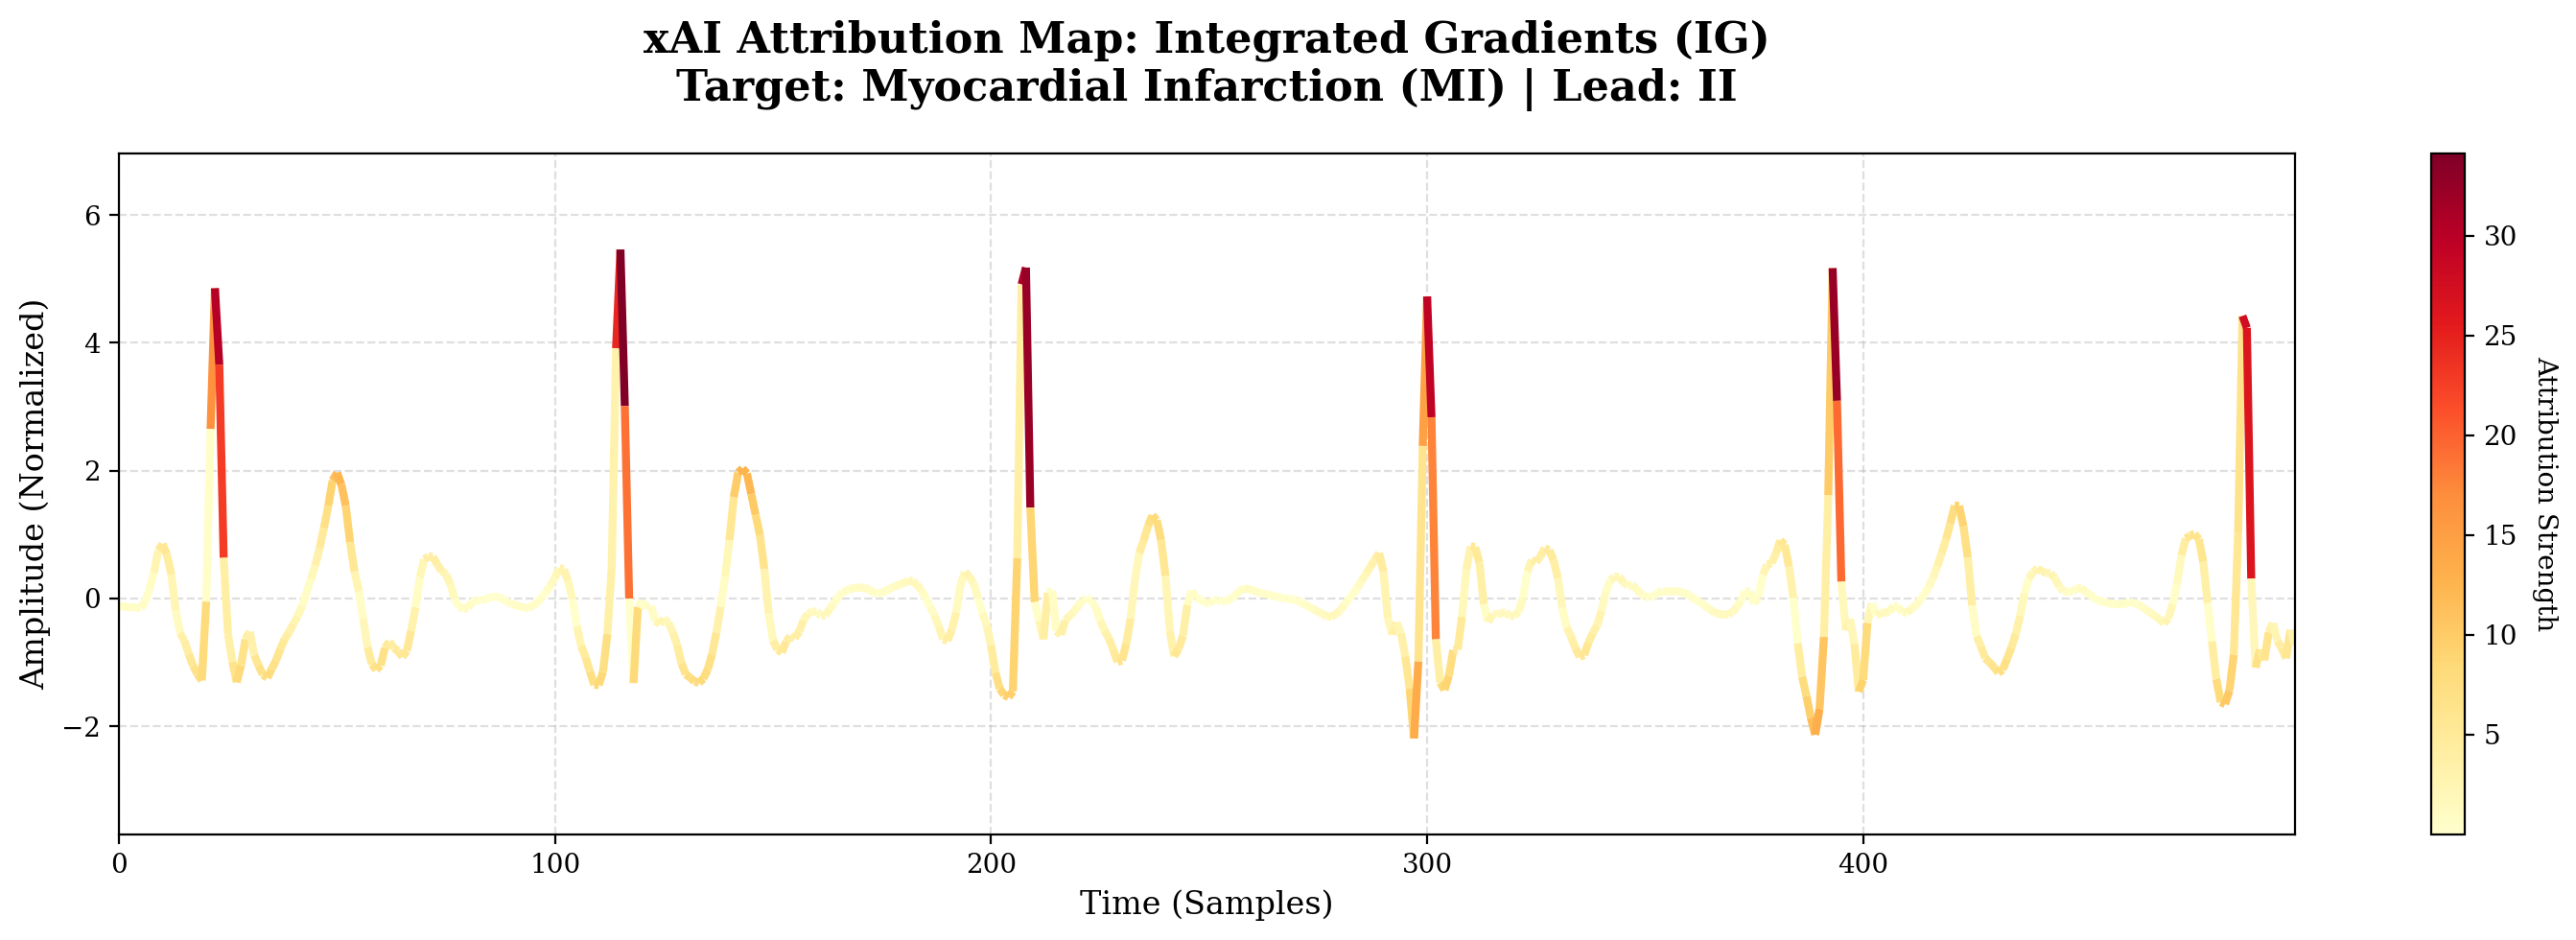

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_signal_with_attribution(signal, attributions, feature_names, lead_idx=0,
                                 method_name="Integrated Gradients", target_name="Myocardial Infarction"):
    """
    Plots the ECG signal with a color-coded attribution overlay and a formal title.
    """
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    lead_name = lead_names[lead_idx]

    lead_indices = [i for i, name in enumerate(feature_names) if name.startswith(lead_name)]
    lead_importance = np.sum(np.abs(attributions[lead_indices]))

    norm_attr = lead_importance / (np.max(np.abs(attributions)) + 1e-8)
    intensity = np.abs(signal) * norm_attr

    x = np.arange(len(signal))
    y = signal
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    fig, ax = plt.subplots(figsize=(15, 5))

    cmap = plt.get_cmap('YlOrRd')
    norm = plt.Normalize(intensity.min(), intensity.max())
    lc = LineCollection(segments, cmap=cmap, norm=norm)

    lc.set_array(intensity)
    lc.set_linewidth(3)
    line = ax.add_collection(lc)


    plt.title(f"xAI Attribution Map: {method_name}\nTarget: {target_name} | Lead: {lead_name}",
              fontsize=16, fontweight='bold', pad=20)

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min() - 1.5, y.max() + 1.5)
    ax.set_xlabel("Time (Samples)", fontsize=12)
    ax.set_ylabel("Amplitude (Normalized)", fontsize=12)

    cbar = fig.colorbar(line, ax=ax)
    cbar.set_label("Attribution Strength", rotation=270, labelpad=15)

    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_signal_with_attribution(
    signal=X_cleaned[0, :500, 1],
    attributions=attr_ig_val,
    feature_names=feature_labels,
    lead_idx=1,
    method_name="Integrated Gradients (IG)",
    target_name="Myocardial Infarction (MI)"
)